# Article -> Country
This notebook bulk computes predictions for all Wikipedia articles based on all the pre-computed signals and then explores various trends in the data.

## Setup

In [1]:
import gzip

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import wmfdata

In [2]:
spark = wmfdata.spark.create_session(app_name='pyspark large; regions; isaacj',
                                  type='yarn-large', # local, yarn-regular, yarn-large
                                  )  

SPARK_HOME: /usr/lib/spark3
Using Hadoop client lib jars at 3.2.0, provided by Spark.
PYSPARK_PYTHON=/opt/conda-analytics/bin/python3


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/07/26 14:22:39 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in mesos/standalone/kubernetes and LOCAL_DIRS in YARN).
24/07/26 14:22:40 WARN Utils: Service 'sparkDriver' could not bind on port 12000. Attempting port 12001.
24/07/26 14:22:40 WARN Utils: Service 'sparkDriver' could not bind on port 12001. Attempting port 12002.
24/07/26 14:22:40 WARN Utils: Service 'sparkDriver' could not bind on port 12002. Attempting port 12003.
24/07/26 14:22:40 WARN Utils: Service 'sparkDriver' could not bind on port 12003. Attempting port 12004.
24/07/26 14:22:40 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
24/07/26 14:22:40 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
24/07/26 14:22:40 WARN Utils: Service 'SparkUI' could n

## Compute data

In [3]:
wikidata_table = 'isaacj.qid_to_country'
print("Wikidata groundtruth snapshots:")
spark.sql(f'SHOW PARTITIONS {wikidata_table}').show(5, False)
spark.sql(f"DESCRIBE {wikidata_table}").show(50, False)

print("Wikilinks groundtruth snapshots:")
wikilinks_table = 'isaacj.qid_to_country_wikilinks_2024_04_01'
spark.sql(f"DESCRIBE {wikilinks_table}").show(50, False)

print("Categories groundtruth snapshots:")
categories_table = 'isaacj.qid_to_country_categories'
spark.sql(f"DESCRIBE {categories_table}").show(50, False)

print("Topics groundtruth snapshots:")
topics_table = 'research.article_topics'
spark.sql(f'SHOW PARTITIONS {topics_table}').show(5, False)
spark.sql(f"DESCRIBE {topics_table}").show(50, False)

Wikidata groundtruth snapshots:
+-------------------+
|partition          |
+-------------------+
|snapshot=2024-04-01|
+-------------------+

+-----------------------+---------+-----------------------------------------------------------------------------+
|col_name               |data_type|comment                                                                      |
+-----------------------+---------+-----------------------------------------------------------------------------+
|qid                    |string   |Wikidata ID of item with at least one Wikipedia sitelink -- e.g., Q42        |
|property               |string   |Wikidata property (e.g., P625 for coordinates) from which country was derived|
|country                |string   |Region name                                                                  |
|snapshot               |string   |Wikidata snapshot processed                                                  |
|# Partition Information|         |                        

In [4]:
def getTopics(predicted_labels):
    try:
        topics = []
        for prediction in predicted_labels:
            if prediction['probability'] >= 0.5:
                topics.append(prediction['label'])
        return topics
    except Exception:
        return None
    
spark.udf.register('getTopics', getTopics, 'Array<String>')

<function __main__.getTopics(predicted_labels)>

In [5]:
wikidata_snapshot = "2024-04-01"
topics_snapshot = "2024-06"

In [8]:
query = f"""
WITH article_topics AS (
    SELECT
      wiki_db,
      pid_from,
      qid_from,
      getTopics(predicted_labels) AS topics
    FROM {topics_table}
    WHERE
      snapshot = '{topics_snapshot}'
),
category_countries AS (
    SELECT
      wiki_db,
      pid_from,
      COLLECT_SET(country) AS category_countries
    FROM {categories_table}
    GROUP BY
      wiki_db,
      pid_from
),
wikilinks_countries AS (
    SELECT
      wiki_db,
      pid_from,
      COLLECT_SET(country) AS wikilink_countries
    FROM {wikilinks_table}
    WHERE
      tfidf >= 0.25
      AND count >= 3
    GROUP BY
      wiki_db,
      pid_from
),
wikidata_countries AS (
    SELECT
      qid,
      COLLECT_SET(country) AS wikidata_countries
    FROM {wikidata_table}
    WHERE
      snapshot = '{wikidata_snapshot}'
    GROUP BY
      qid
)
SELECT
  top.wiki_db AS wiki_db,
  top.pid_from AS page_id,
  top.qid_from AS qid_from,
  CONCAT_WS("|", top.topics) AS topics,
  CONCAT_WS("|", category_countries) AS category_countries,
  CONCAT_WS("|", wikilink_countries) AS wikilink_countries,
  CONCAT_WS("|", wikidata_countries) AS wikidata_countries
FROM article_topics top
LEFT JOIN category_countries cat
  ON (top.pid_from = cat.pid_from
      AND top.wiki_db = cat.wiki_db)
LEFT JOIN wikilinks_countries link
  ON (top.pid_from = link.pid_from
      AND top.wiki_db = link.wiki_db)
LEFT JOIN wikidata_countries wd
  ON (top.qid_from = wd.qid)
"""

print(query)
spark.sql(query).coalesce(1).write.csv(
    path=f"/user/isaacj/region-predictions-2024-Juneish",
    compression="gzip",
    header=True,
    sep="\t")


WITH article_topics AS (
    SELECT
      wiki_db,
      pid_from,
      qid_from,
      getTopics(predicted_labels) AS topics
    FROM research.article_topics
    WHERE
      snapshot = '2024-06'
),
category_countries AS (
    SELECT
      wiki_db,
      pid_from,
      COLLECT_SET(country) AS category_countries
    FROM isaacj.qid_to_country_categories
    GROUP BY
      wiki_db,
      pid_from
),
wikilinks_countries AS (
    SELECT
      wiki_db,
      pid_from,
      COLLECT_SET(country) AS wikilink_countries
    FROM isaacj.qid_to_country_wikilinks_2024_04_01
    WHERE
      tfidf >= 0.25
      AND count >= 3
    GROUP BY
      wiki_db,
      pid_from
),
wikidata_countries AS (
    SELECT
      qid,
      COLLECT_SET(country) AS wikidata_countries
    FROM isaacj.qid_to_country
    WHERE
      snapshot = '2024-04-01'
    GROUP BY
      qid
)
SELECT
  top.wiki_db AS wiki_db,
  top.pid_from AS page_id,
  top.qid_from AS qid_from,
  CONCAT_WS("|", top.topics) AS topics,
  CONCAT_WS(

24/07/26 14:23:10 WARN SessionState: METASTORE_FILTER_HOOK will be ignored, since hive.security.authorization.manager is set to instance of HiveAuthorizerFactory.


In [9]:
!hdfs dfs -ls region-predictions-2024-Juneish

Found 2 items
-rw-r-----   3 isaacj isaacj          0 2024-07-26 14:33 region-predictions-2024-Juneish/_SUCCESS
-rw-r-----   3 isaacj isaacj  877961082 2024-07-26 14:33 region-predictions-2024-Juneish/part-00000-b29825df-b500-4614-899e-e938d27f6685-c000.csv.gz


In [11]:
!hdfs dfs -copyToLocal region-predictions-2024-Juneish/part-00000-b29825df-b500-4614-899e-e938d27f6685-c000.csv.gz region-predictions-2024-Juneish.tsv.gz

In [12]:
!zless region-predictions-2024-Juneish.tsv.gz | wc -l
!zless region-predictions-2024-Juneish.tsv.gz | head

62991275
wiki_db	page_id	qid_from	topics	category_countries	wikilink_countries	wikidata_countries
enwiki	1438941	Q1000098	Geography.Regions.Asia.East_Asia|Geography.Regions.Asia.Asia*	""	Japan	Japan
jawiki	82776	Q1000098	Geography.Regions.Asia.Asia*|Geography.Regions.Asia.East_Asia	""	Japan	Japan
kowiki	3054810	Q1000098	Geography.Regions.Asia.East_Asia|Geography.Regions.Asia.Asia*	""	Japan	Japan
zhwiki	643793	Q1000098	Geography.Regions.Asia.Asia*|Geography.Regions.Asia.East_Asia	""	Japan	Japan
huwiki	1719217	Q1000372	""	""	""	""
enwiki	65511505	Q100137735	Culture.Sports|Culture.Biography.Biography*|Geography.Regions.Americas.North_America	""	United States	""
frwiki	13620463	Q100142506	History_and_Society.Military_and_warfare	""	""	""
shwiki	1460128	Q1001499	Geography.Regions.Europe.Europe*|Geography.Regions.Europe.Eastern_Europe	""	Slovakia	Slovakia
cawiki	1237796	Q1001499	Geography.Regions.Europe.Eastern_Europe|Geography.Regions.Europe.Europe*	""	Slovakia	Slovakia
^C


In [15]:
predictions_tsv = "region-predictions-2024-Juneish.tsv.gz"
expected_header = ['wiki_db', 'page_id', 'qid_from', 'topics', 'category_countries', 'wikilink_countries', 'wikidata_countries']
wiki_idx = expected_header.index('wiki_db')
topics_idx = expected_header.index('topics')
cat_idx = expected_header.index('category_countries')
link_idx = expected_header.index('wikilink_countries')
wd_idx = expected_header.index('wikidata_countries')
data = {}
article_count = {}
null_geo = set(['""'])
with gzip.open(predictions_tsv, 'rt') as fin:
    assert next(fin).strip().split('\t') == expected_header
    for i, line in enumerate(fin, start=1):
        try:
            line = line.strip().split('\t')
            wiki = line[wiki_idx]
            article_count[wiki] = article_count.get(wiki, 0) + 1
            if wiki not in data:
                data[wiki] = {}
            category_countries = line[cat_idx].split('|')
            wikilink_countries = line[link_idx].split('|')
            wikidata_countries = line[wd_idx].split('|')
            all_countries = set(category_countries + wikilink_countries + wikidata_countries)
            country_alignment = {}
            if all_countries == null_geo:
                country_alignment['no-geo'] = 'all-none'
            elif all_countries:
                for c in all_countries:
                    if c != '""':
                        if c in wikidata_countries and c in wikilink_countries and c in category_countries:
                            country_alignment[c] = 'all'
                        elif c in wikidata_countries and c in wikilink_countries:
                            country_alignment[c] = 'wikidata-wikilink'
                        elif c in wikidata_countries and c in category_countries:
                            country_alignment[c] = 'wikidata-category'
                        elif c in wikilink_countries and c in category_countries:
                            country_alignment[c] = 'wikilink-category'
                        elif c in wikidata_countries:
                            country_alignment[c] = 'wikidata'
                        elif c in wikilink_countries:
                            country_alignment[c] = 'wikilink'
                        elif c in category_countries:
                            country_alignment[c] = 'category'
            else:
                print(f"Unexpected countries: {link}")

            topics = line[topics_idx].split('|') + ['all-articles']
            for topic in topics:
                if topic == '""':
                    topic = 'no-topic'
                if topic not in data[wiki]:
                    data[wiki][topic] = {}
                data[wiki][topic]['article-count'] = data[wiki][topic].get('article-count', 0) + 1
                for country, alignment in country_alignment.items():
                    if country not in data[wiki][topic]:
                        data[wiki][topic][country] = {}
                    data[wiki][topic][country][alignment] = data[wiki][topic][country].get(alignment, 0) + 1
        except Exception:
            print(f"Skipping: {line}")
            
        if i % 5000000 == 0:
            print(f"{i} of 62,991,274 articles processed.")

5000000 of 62,991,274 articles processed.
10000000 of 62,991,274 articles processed.
15000000 of 62,991,274 articles processed.
20000000 of 62,991,274 articles processed.
25000000 of 62,991,274 articles processed.
30000000 of 62,991,274 articles processed.
35000000 of 62,991,274 articles processed.
40000000 of 62,991,274 articles processed.
45000000 of 62,991,274 articles processed.
50000000 of 62,991,274 articles processed.
55000000 of 62,991,274 articles processed.
60000000 of 62,991,274 articles processed.


In [13]:
alignment_order = ['all', 'wikidata-wikilink', 'wikidata-category', 'wikilink-category', 'wikidata', 'wikilink', 'category', 'all-none']

def analyze_model_performance(sample_df, x_axis='country', y_axis='alignment', y_axis_order=alignment_order, keep_k=-1, title=None):
    # build confusion matrix for test results by quality class
    confusion_matrix = sample_df.groupby([x_axis, y_axis])['count'].sum().unstack().fillna(0)
    confusion_matrix.columns.name = x_axis
    confusion_matrix.index.name = y_axis
    for c in agg_order:
        if c not in confusion_matrix.columns:
            confusion_matrix[c] = 0
    counts = confusion_matrix.sum(axis=1).sort_values(ascending=False)
    confusion_matrix = confusion_matrix.reindex(counts.index)
    if keep_k > 0 and len(confusion_matrix) > keep_k:
        long_tail = confusion_matrix[keep_k:].sum()
        long_tail.name = 'other'
        confusion_matrix = pd.concat([confusion_matrix[:keep_k], pd.DataFrame(long_tail).T])
        counts = confusion_matrix.sum(axis=1)
    counts = counts.to_dict()
    counts = {c:f"{c} ({int(v)})" for c,v in counts.items()}
    confusion_matrix = confusion_matrix.rename(index=counts)
    confusion_matrix = confusion_matrix[agg_order]
    
    # normalize confusion matrix and visualize
    confusion_matrix = confusion_matrix.div(confusion_matrix.sum(axis=1) + 0.001, axis=0)  # avoid division by zero
    fig, ax = plt.subplots(figsize=(9, 6))
    _ = sns.heatmap(confusion_matrix, annot=True).set(title=title)

/tmp/ipykernel_1694089/36922227.py:25: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(9, 6))


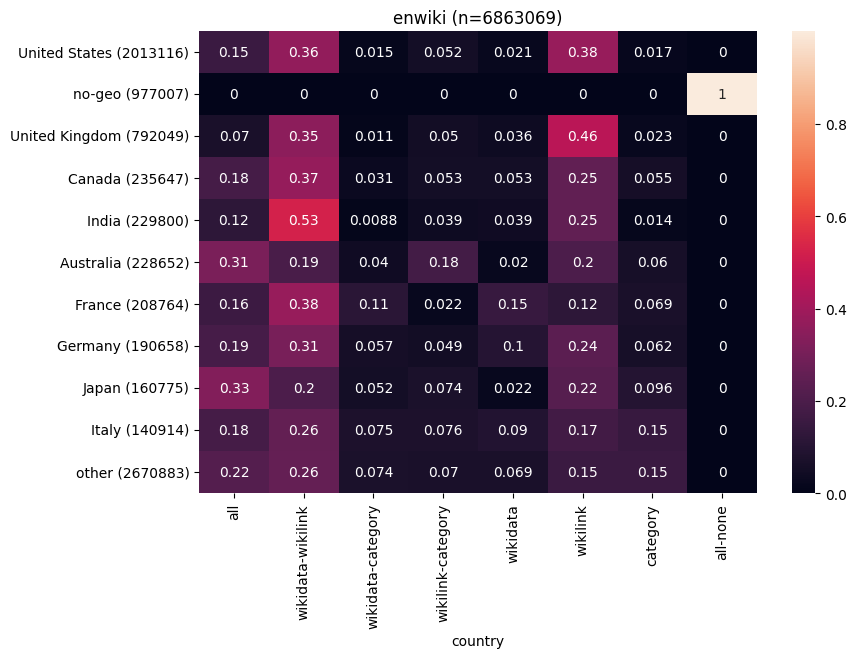

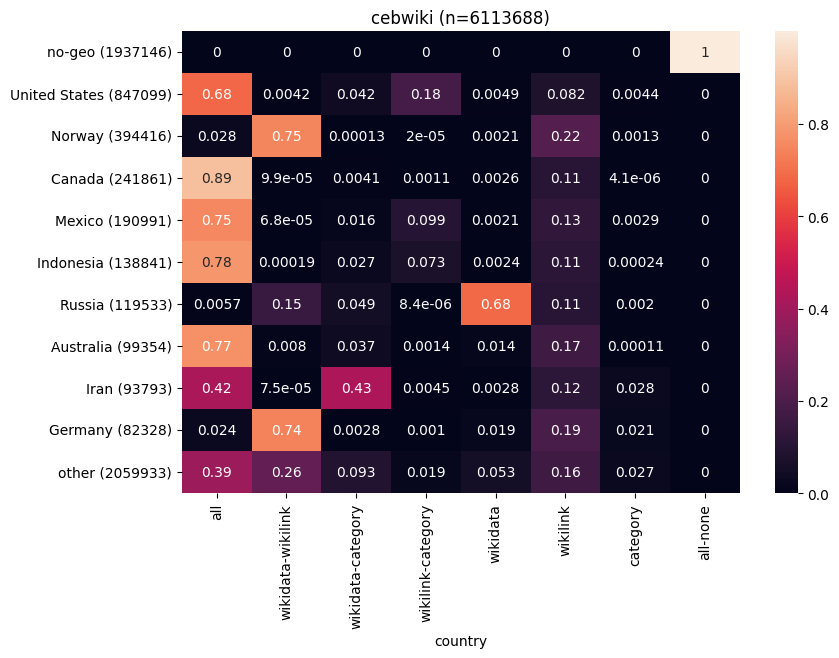

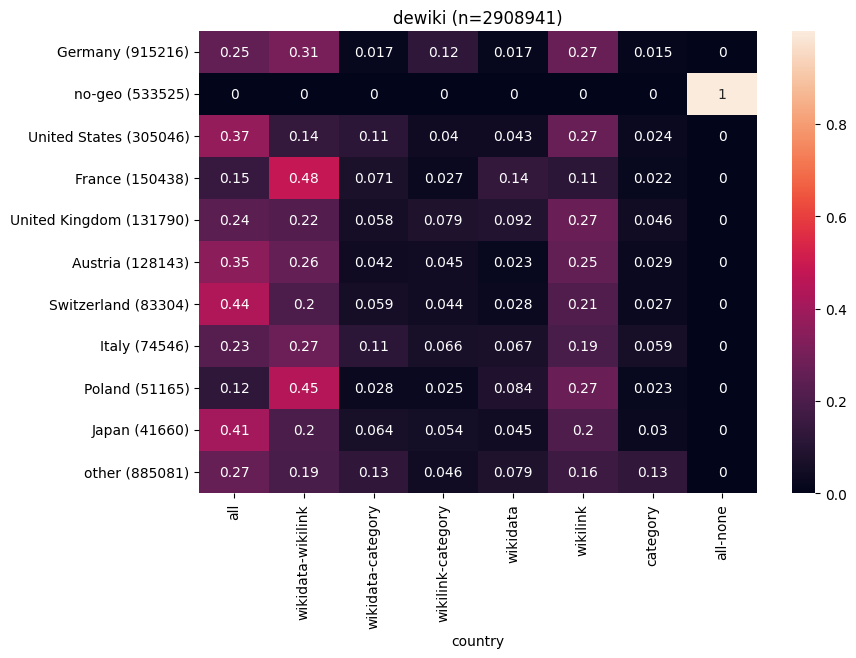

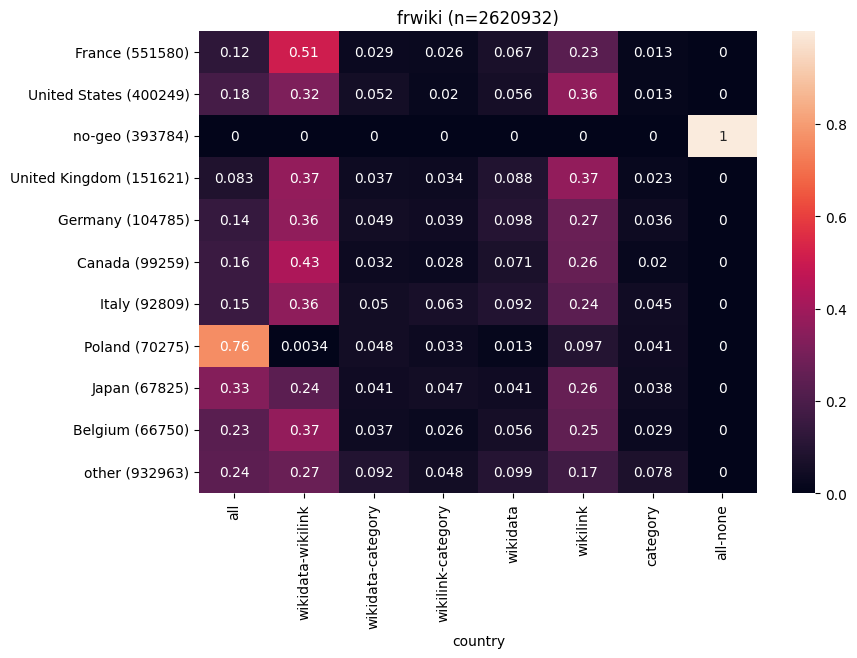

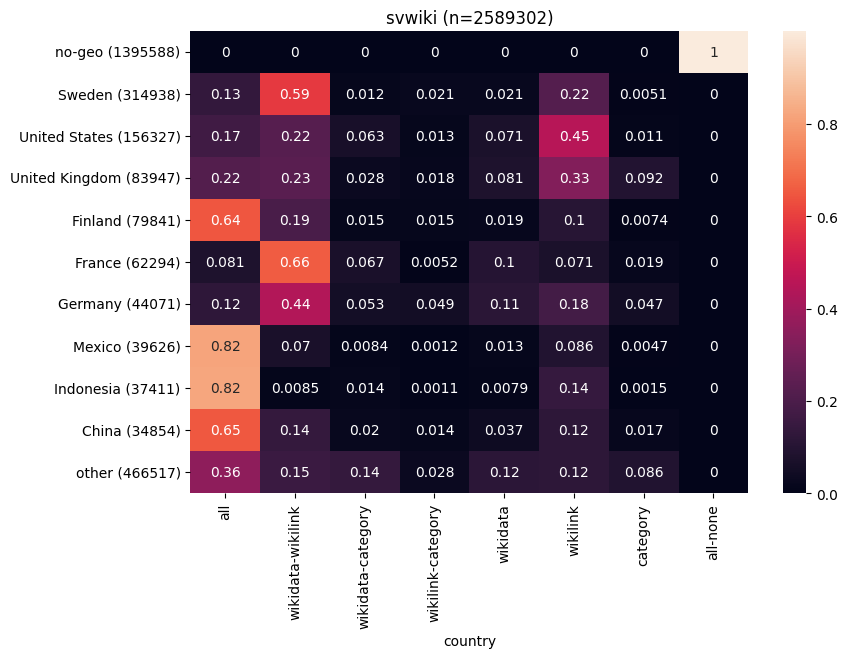

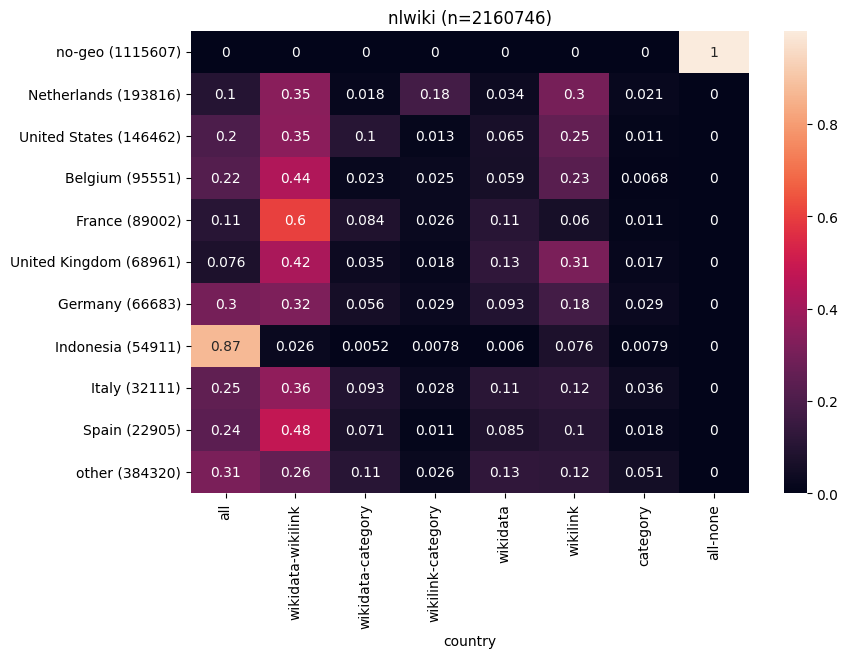

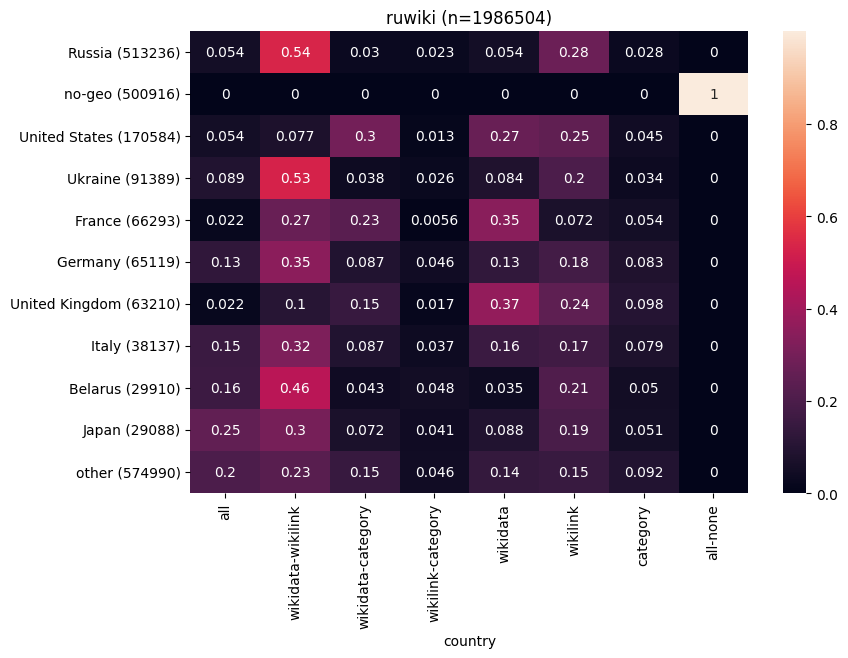

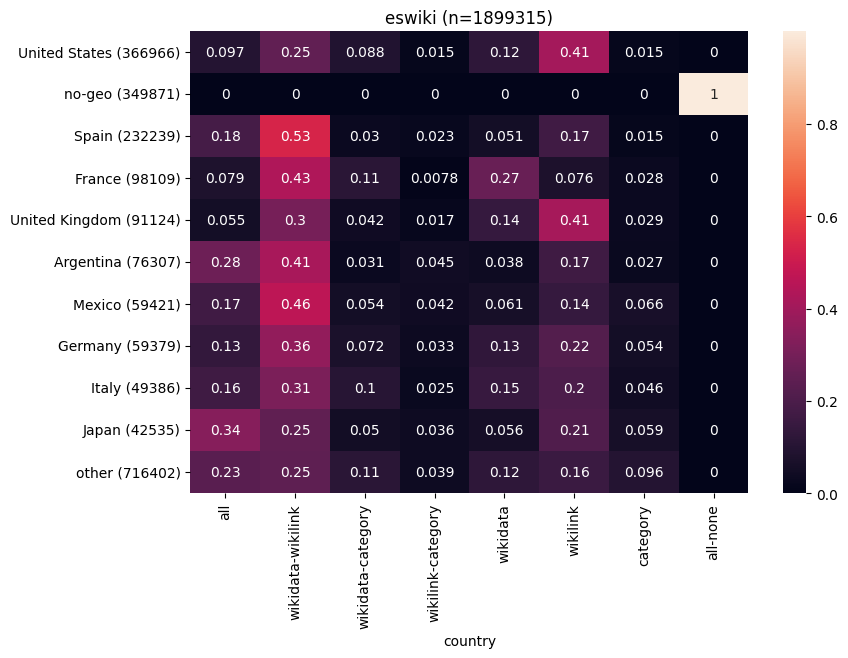

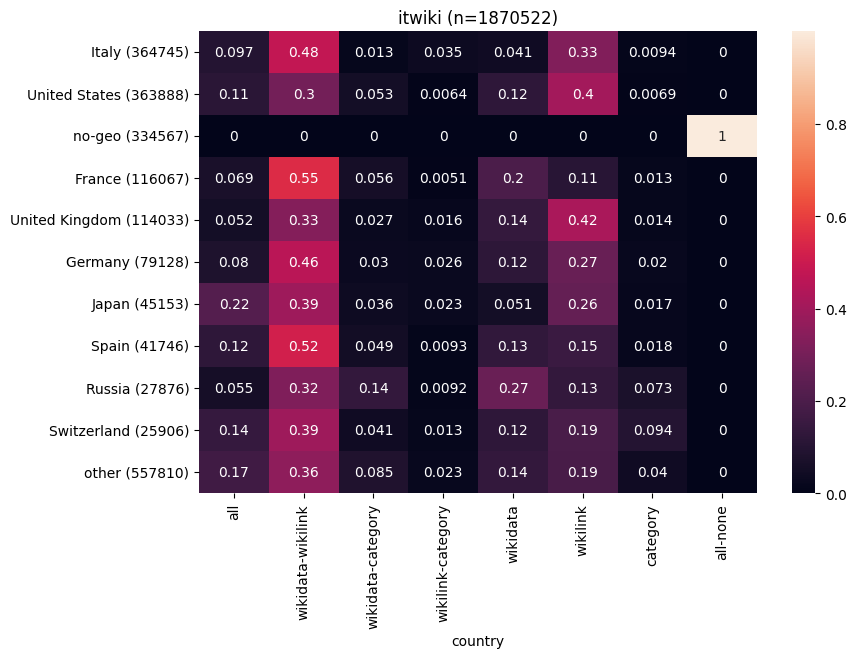

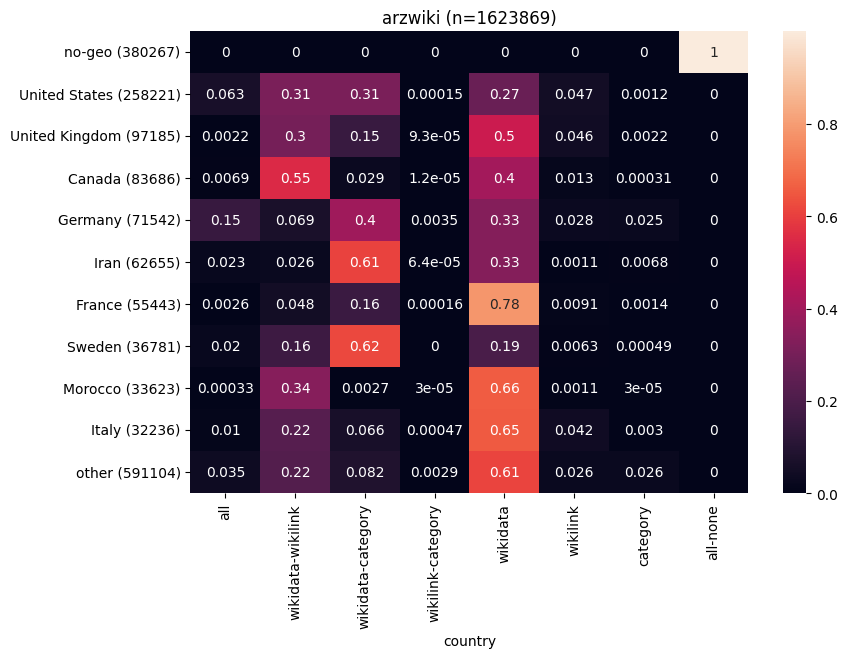

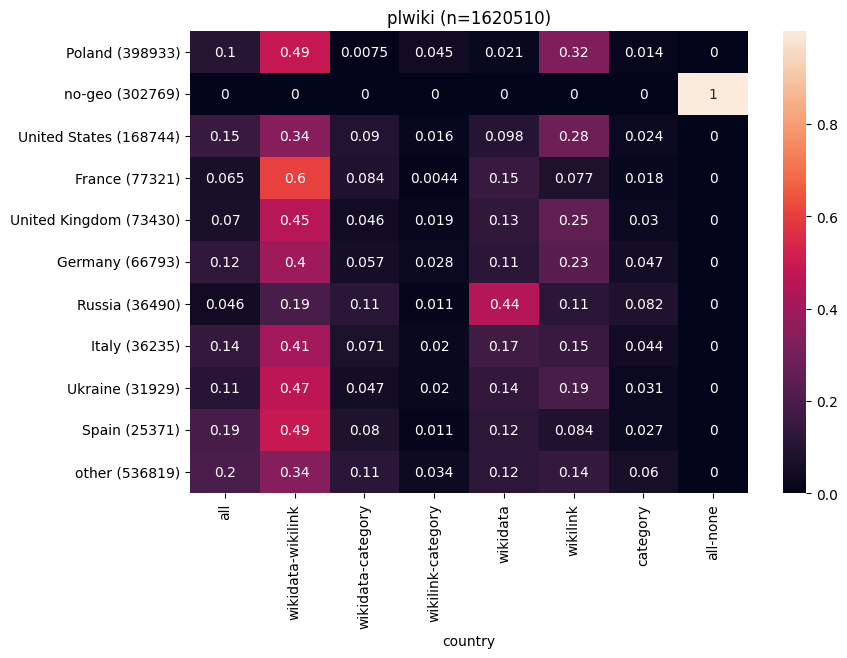

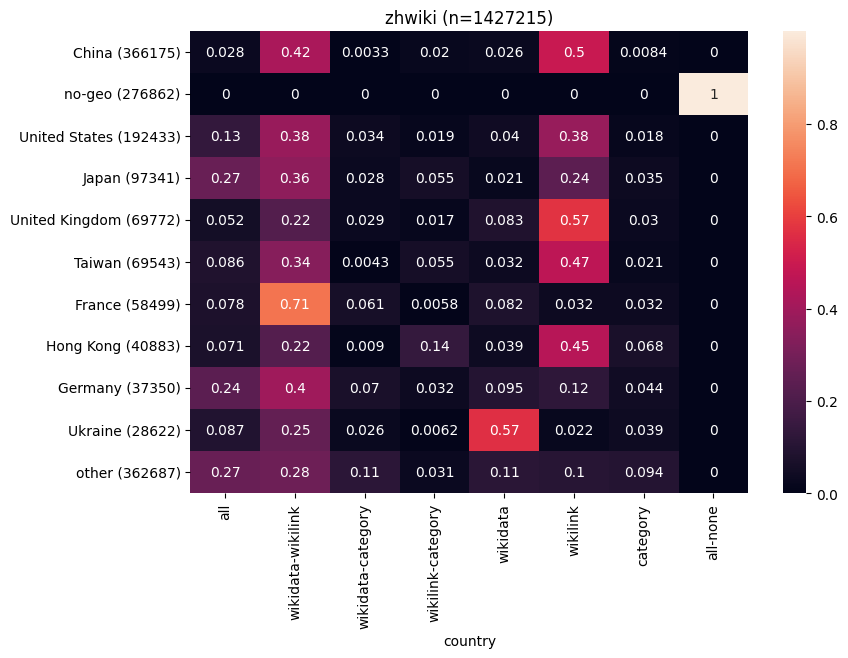

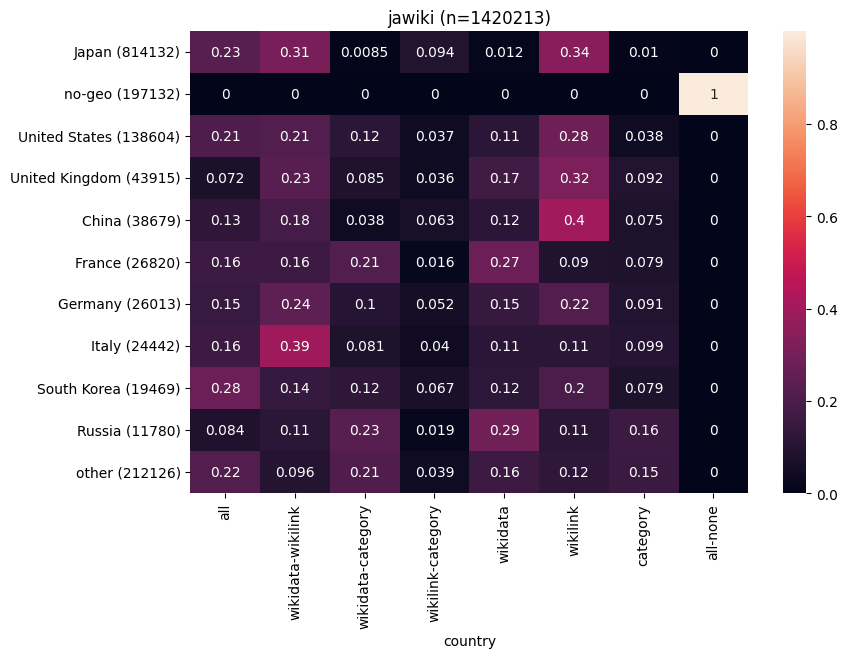

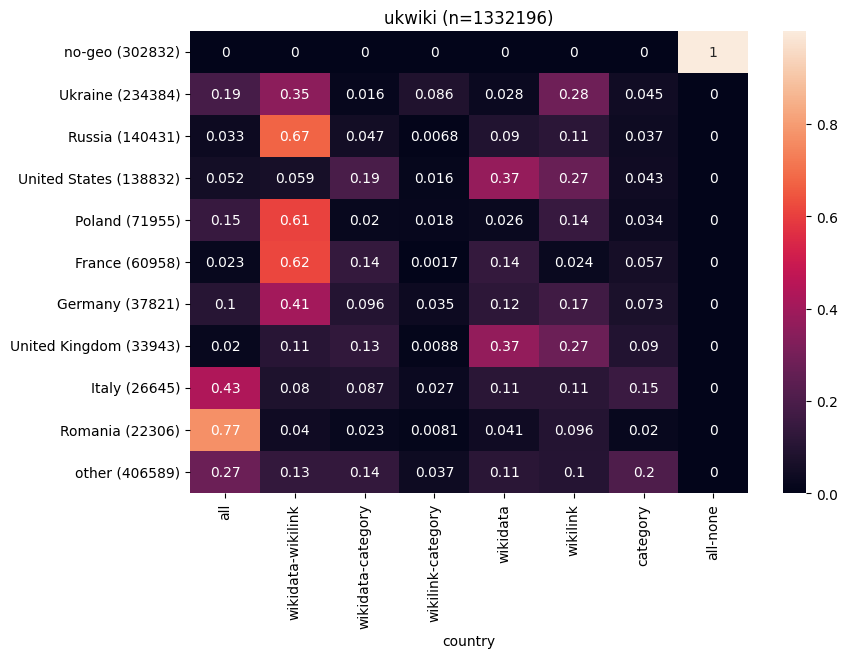

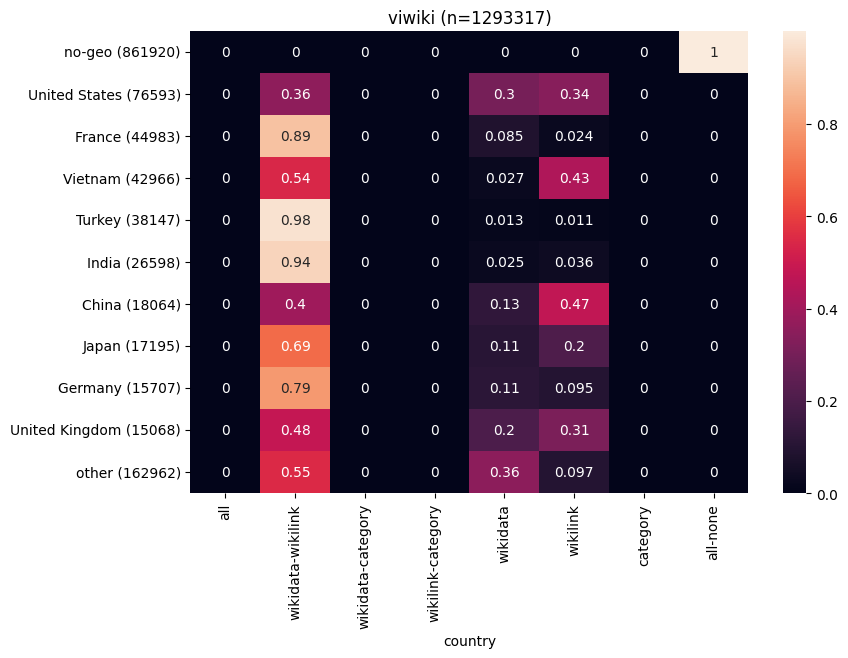

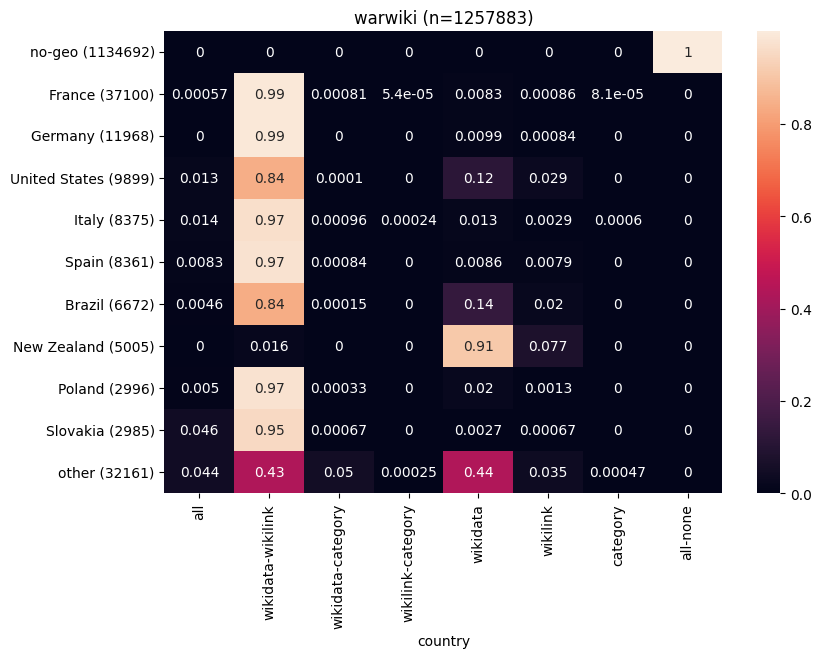

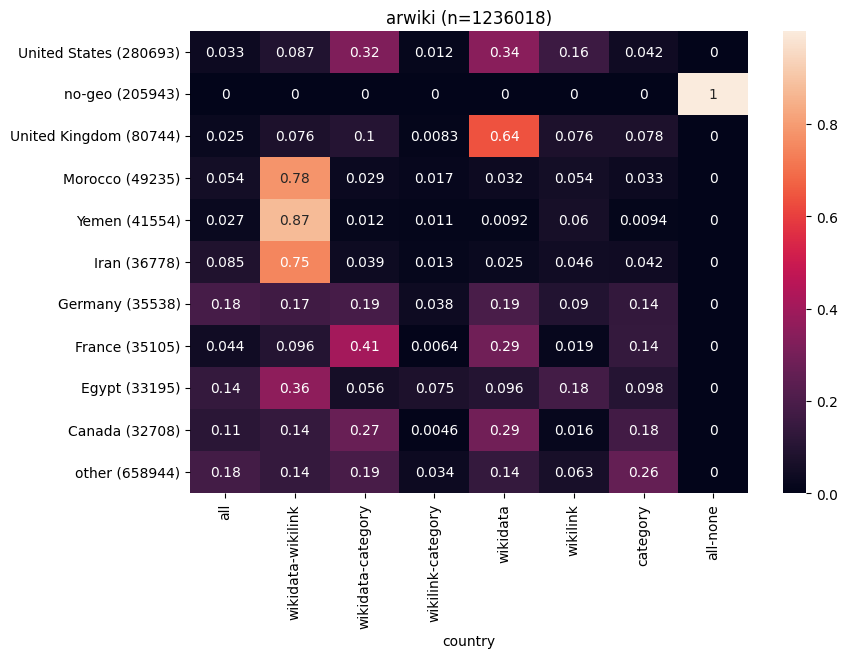

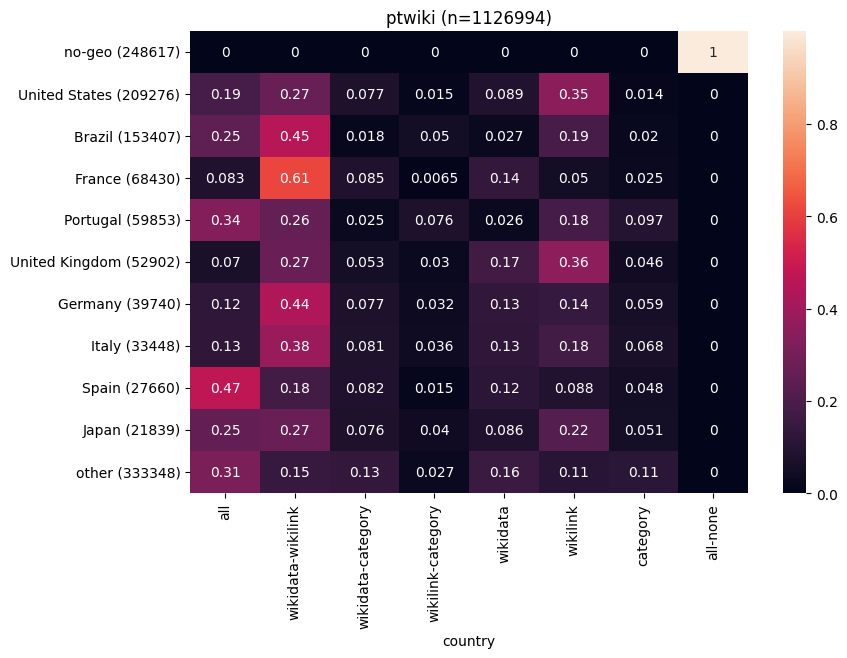

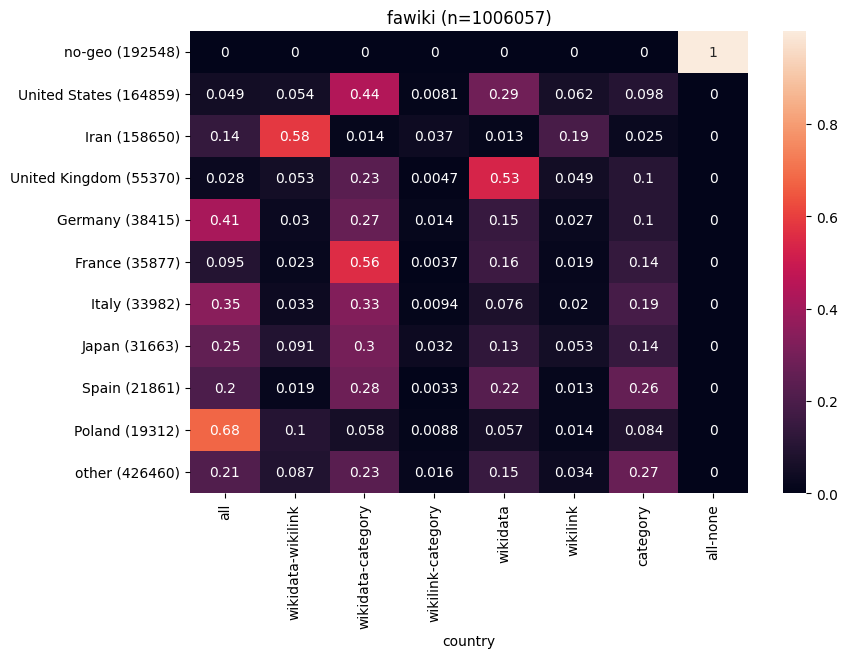

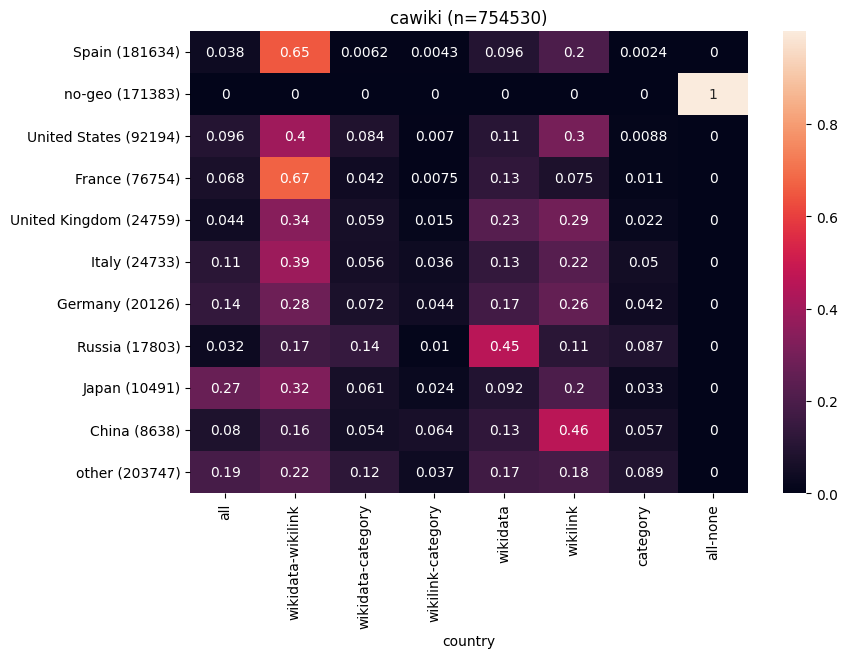

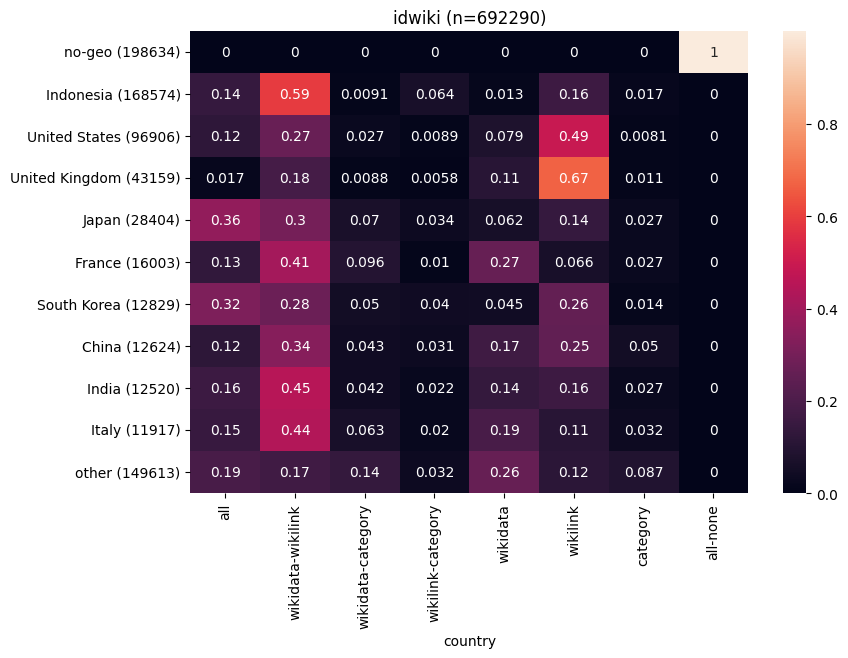

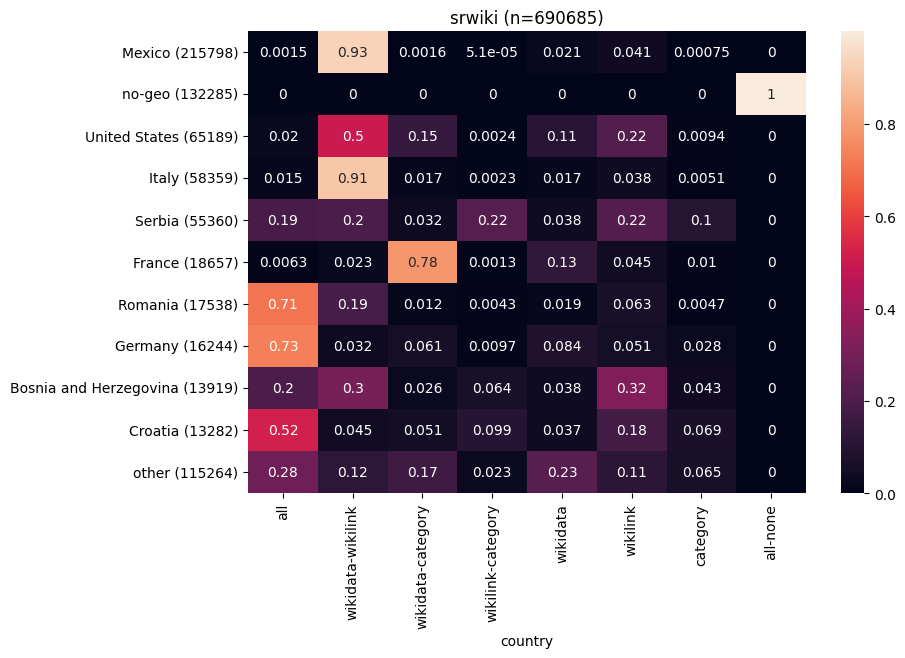

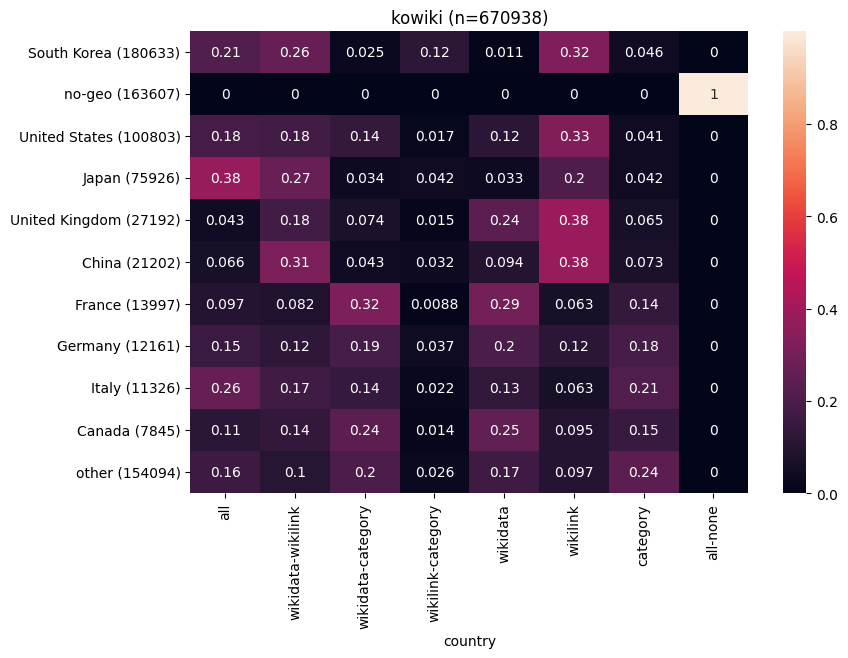

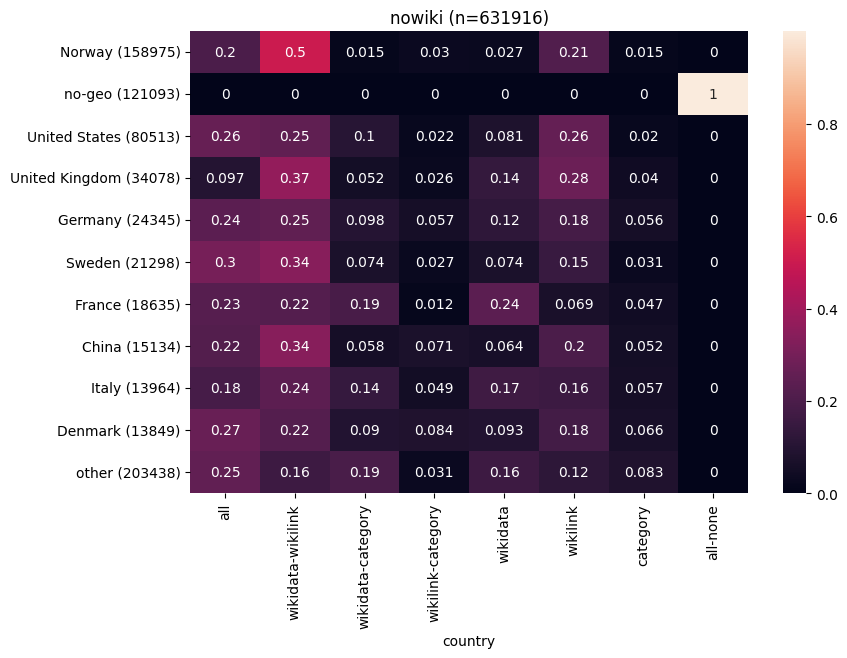

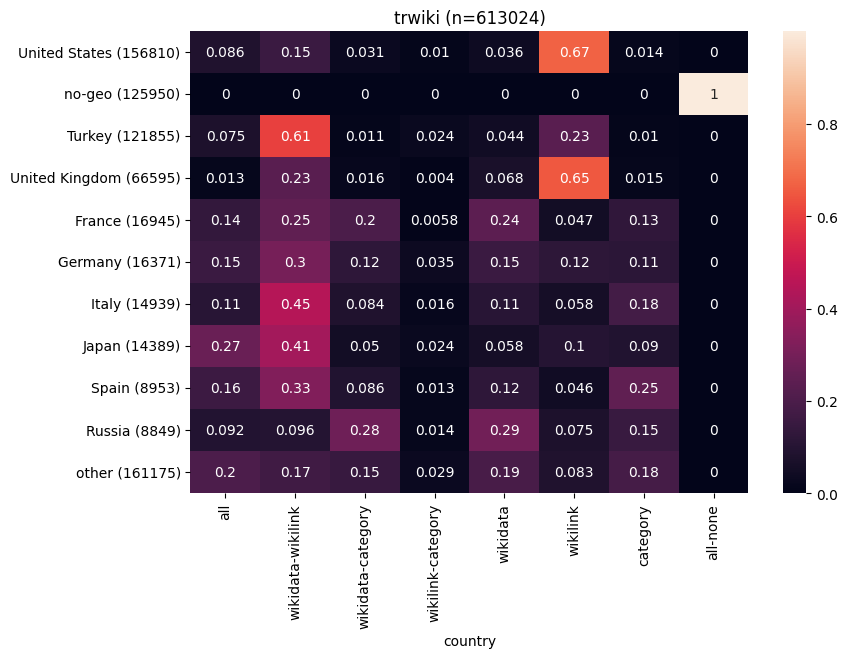

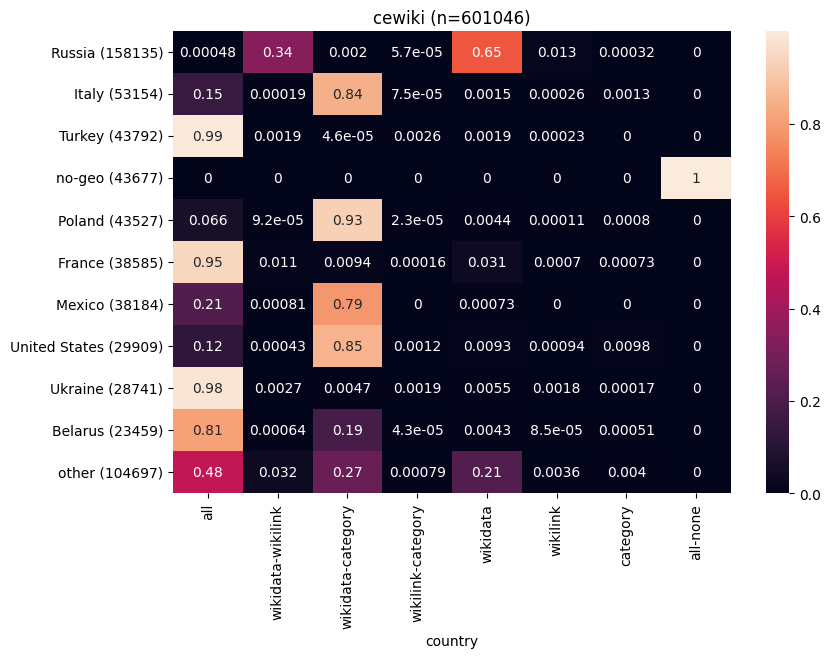

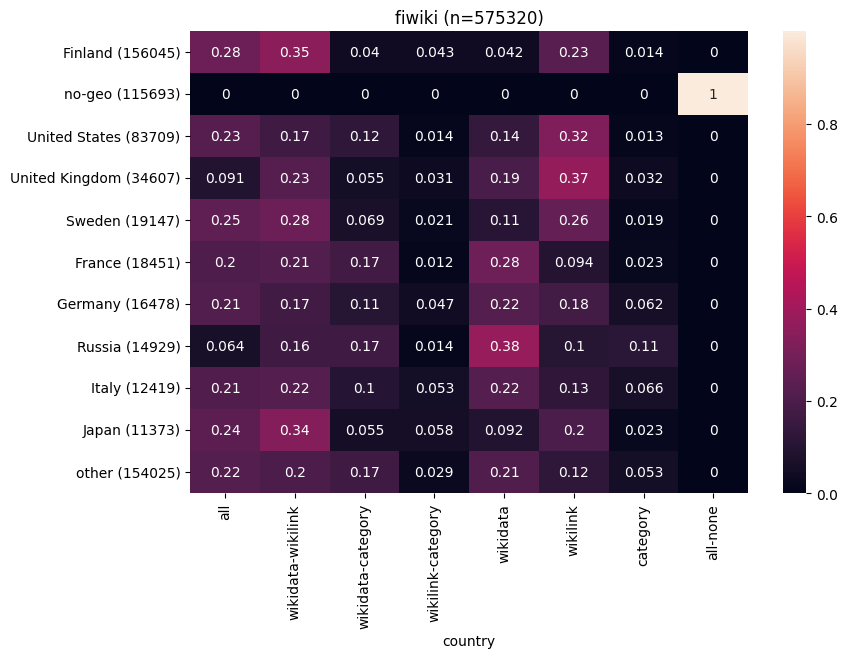

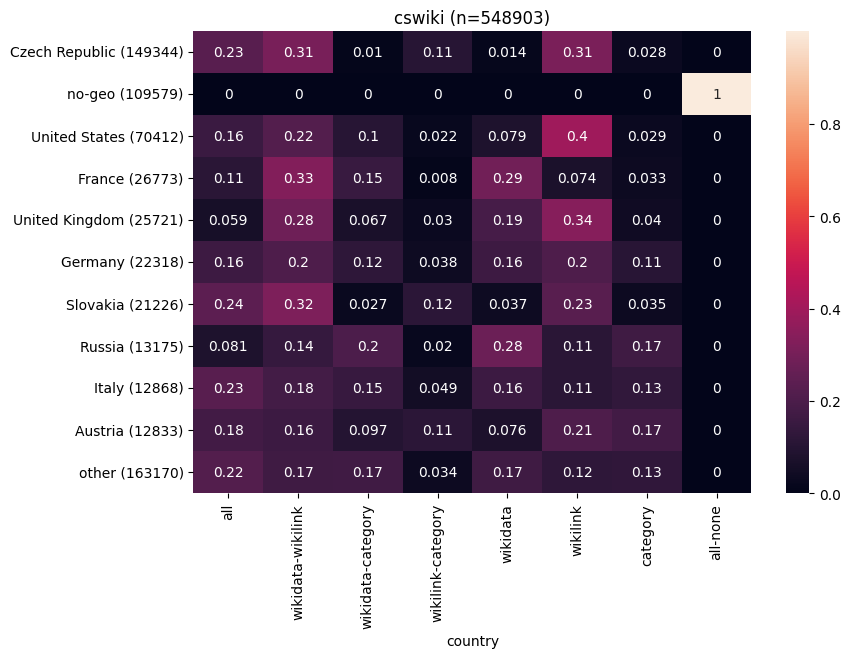

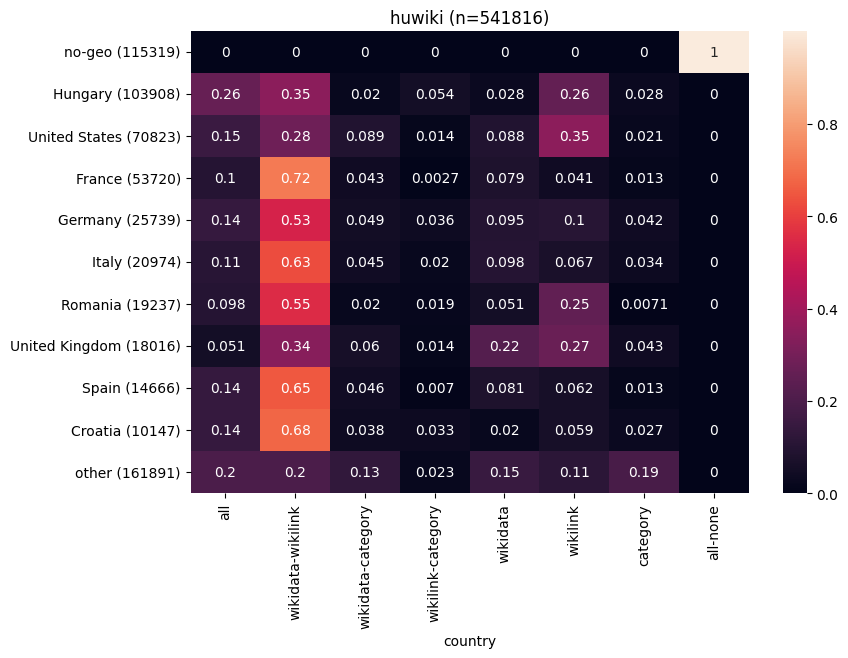

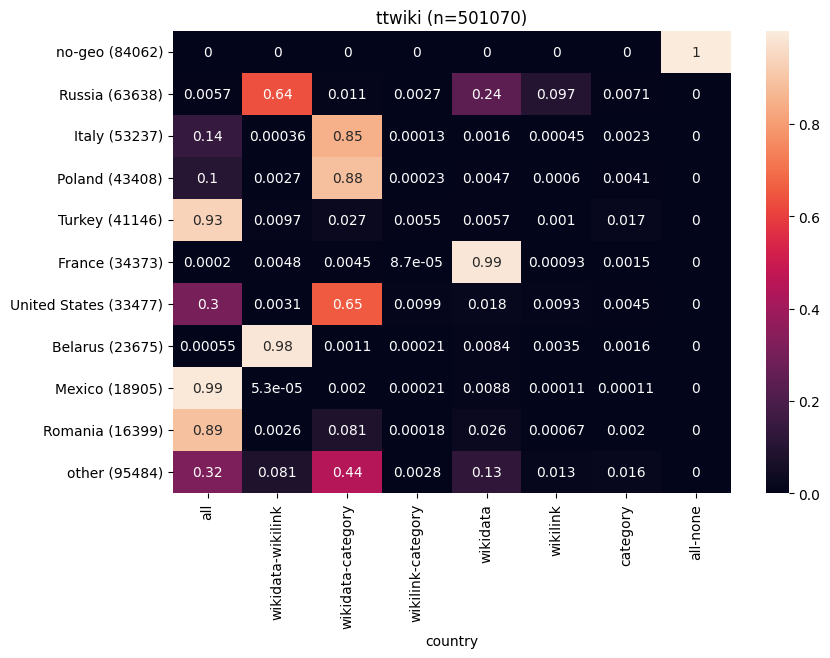

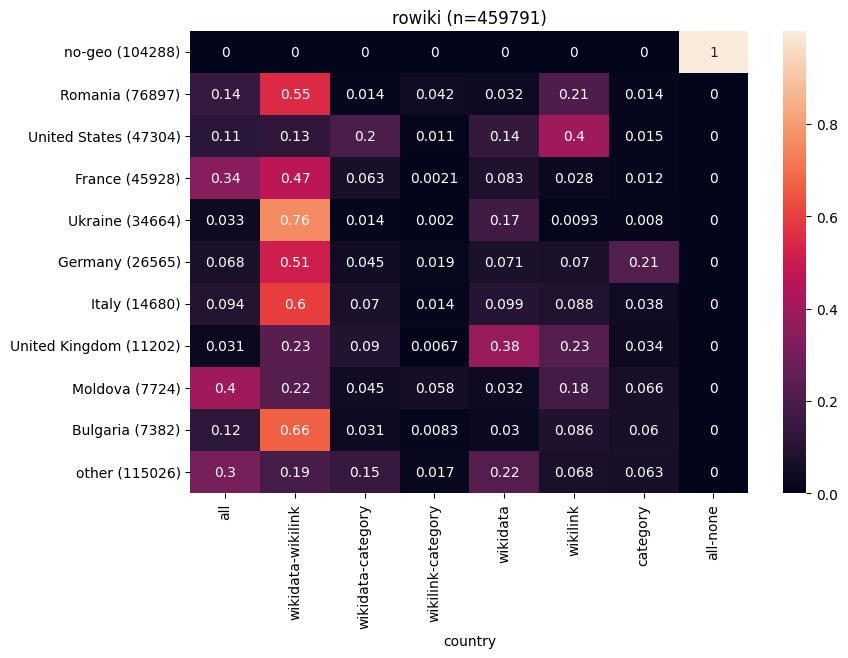

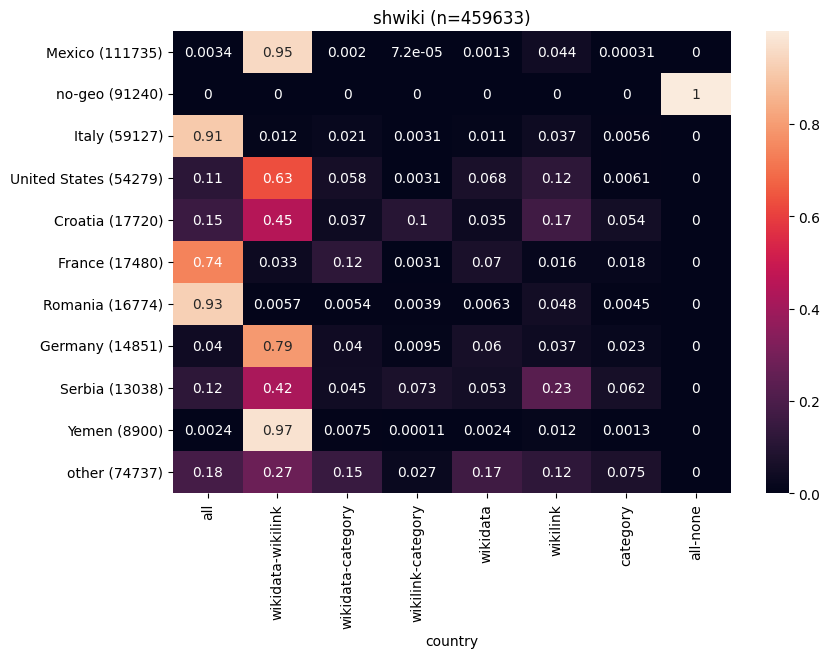

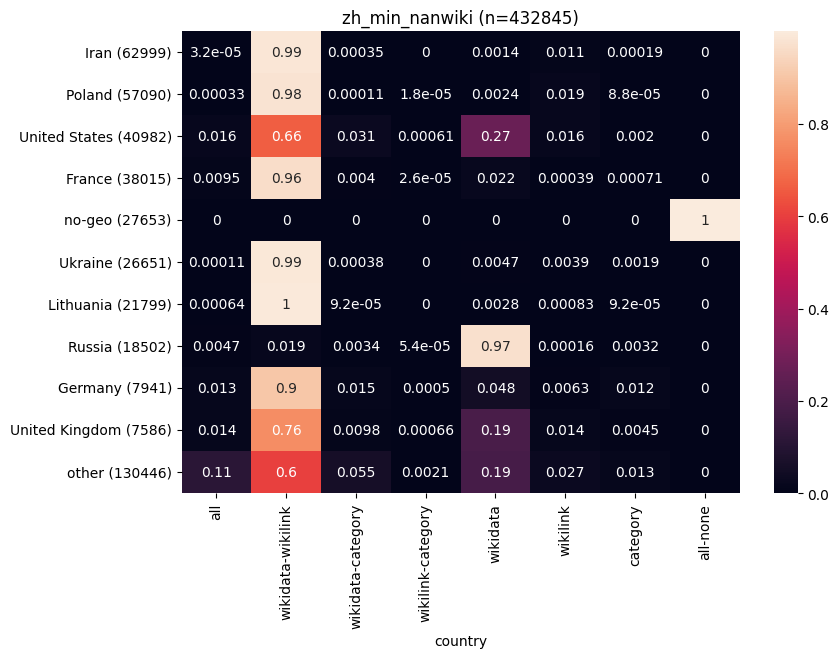

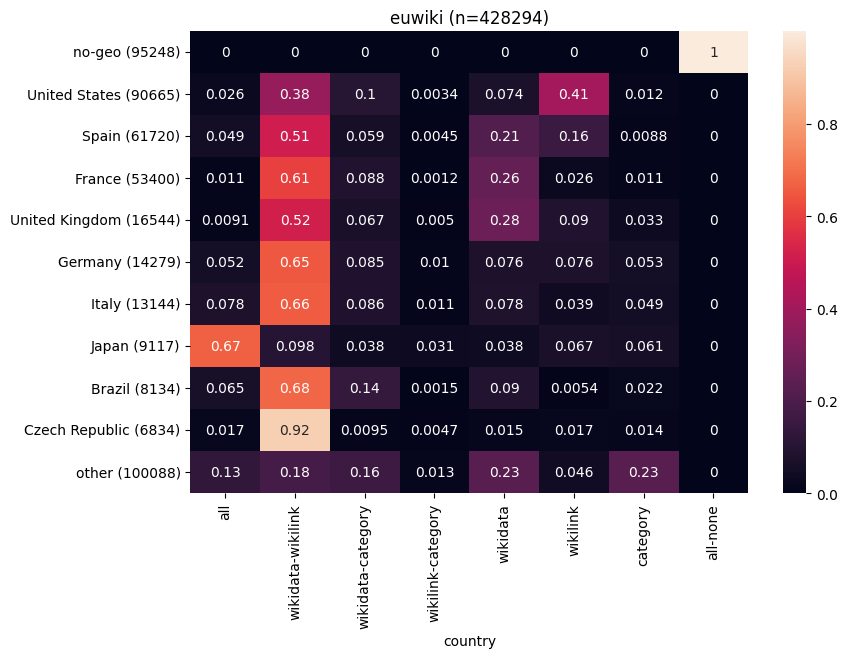

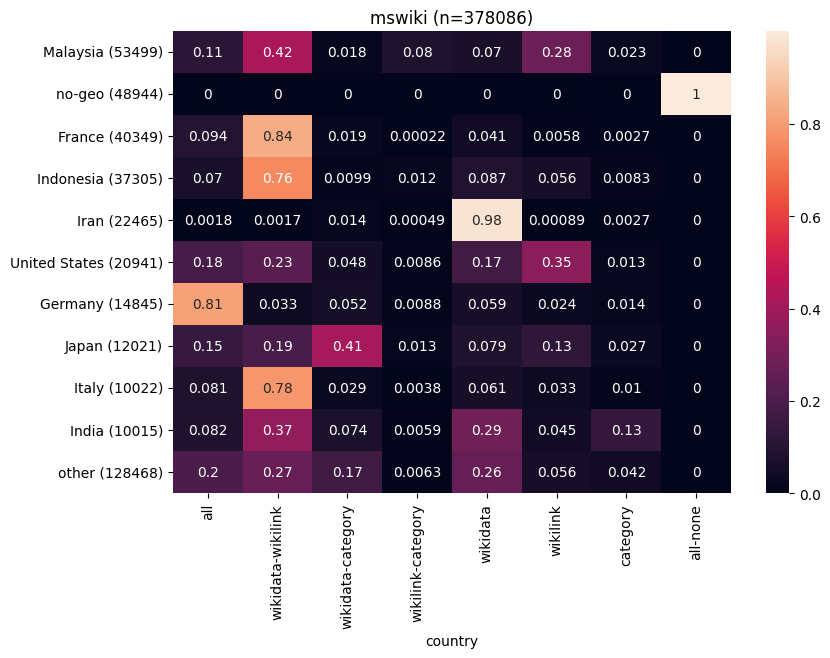

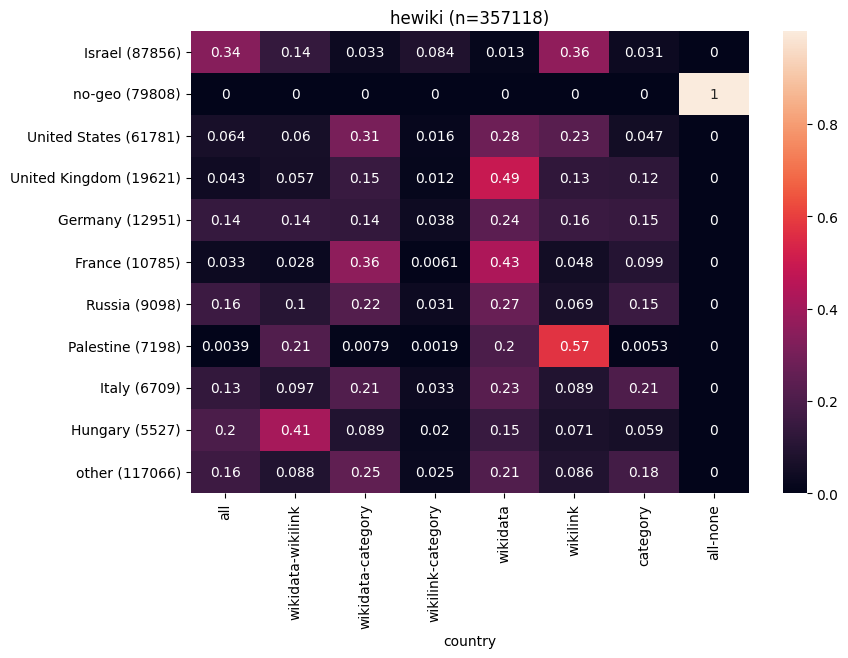

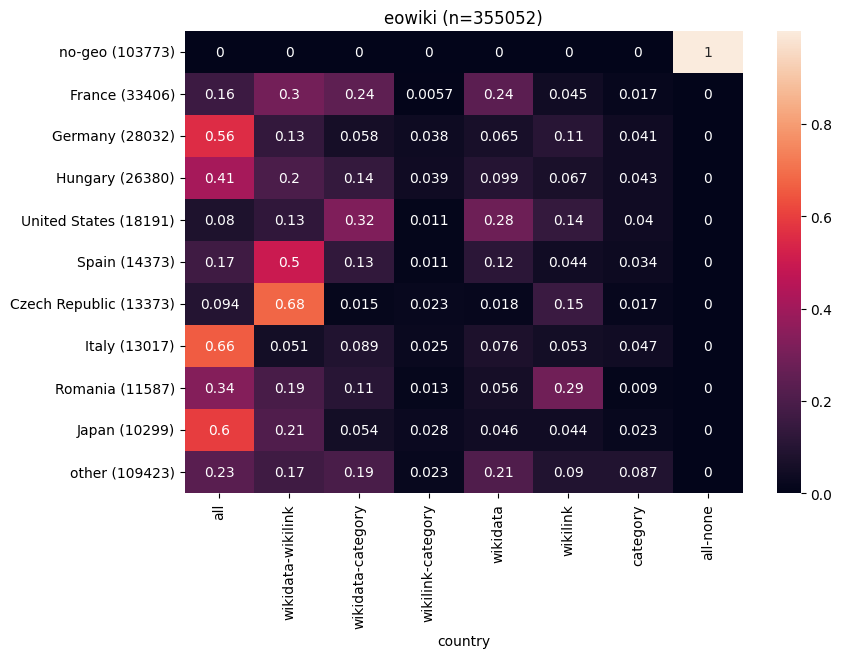

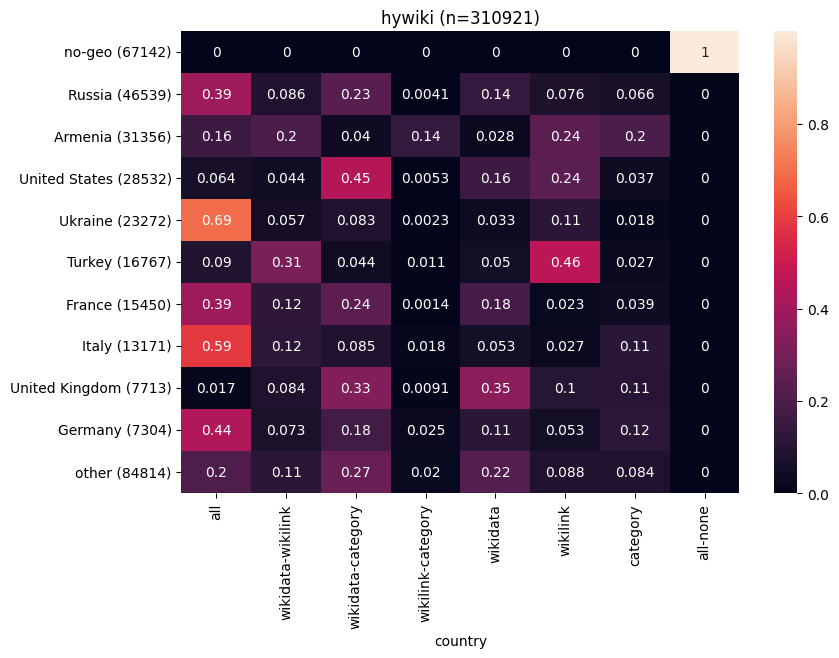

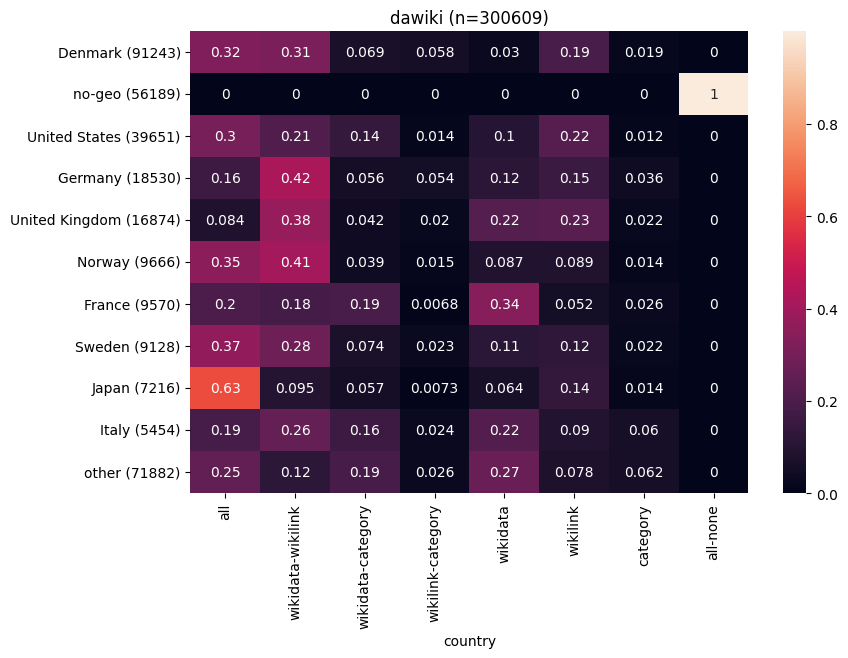

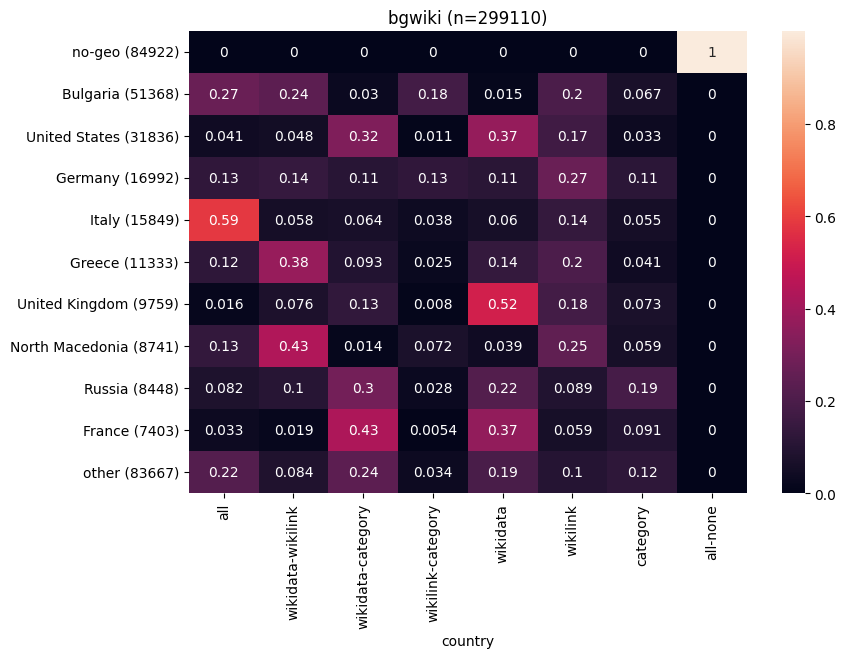

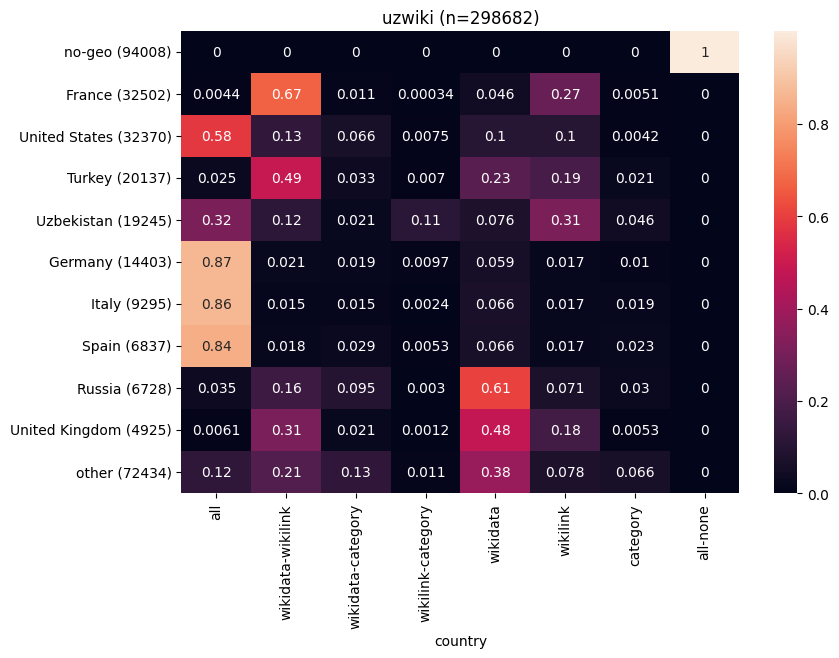

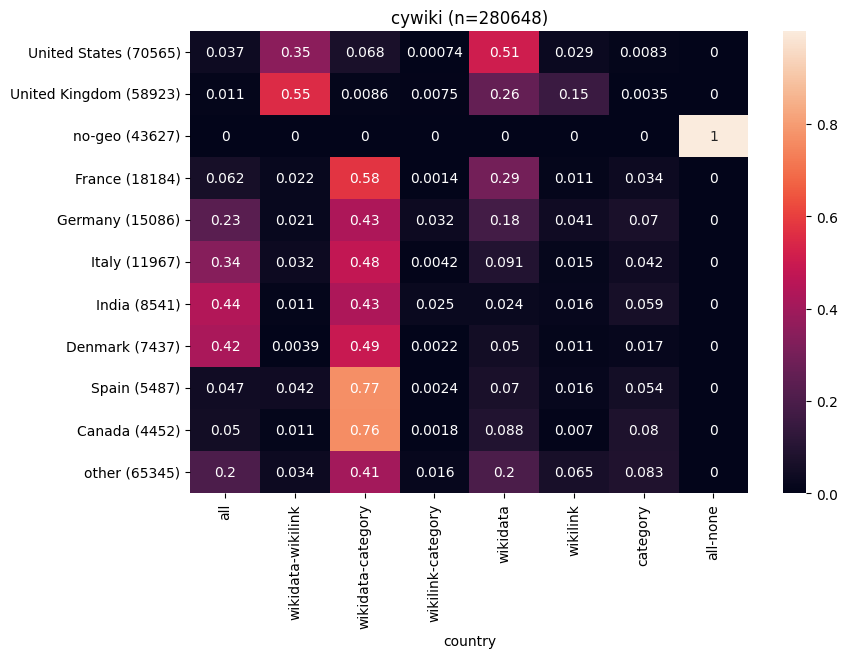

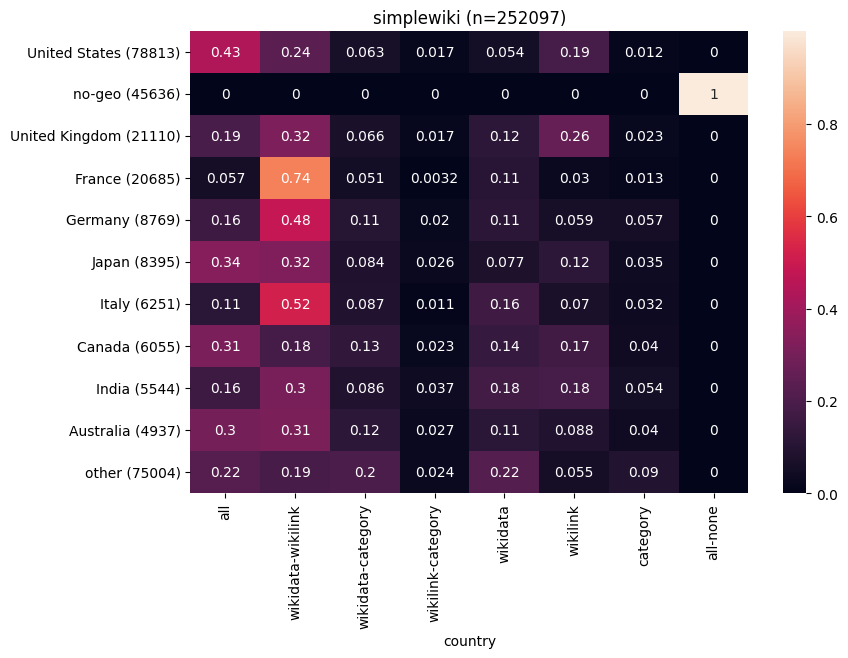

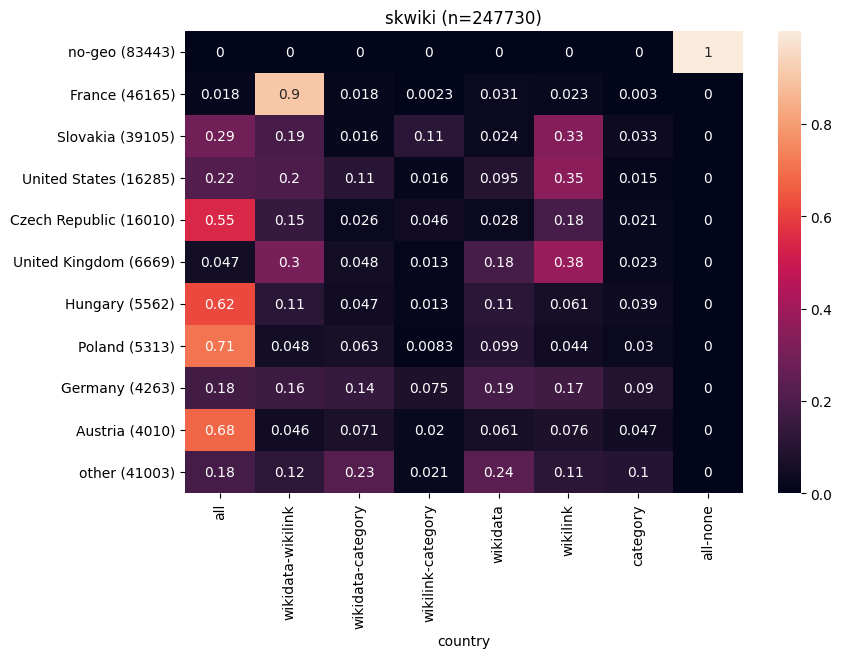

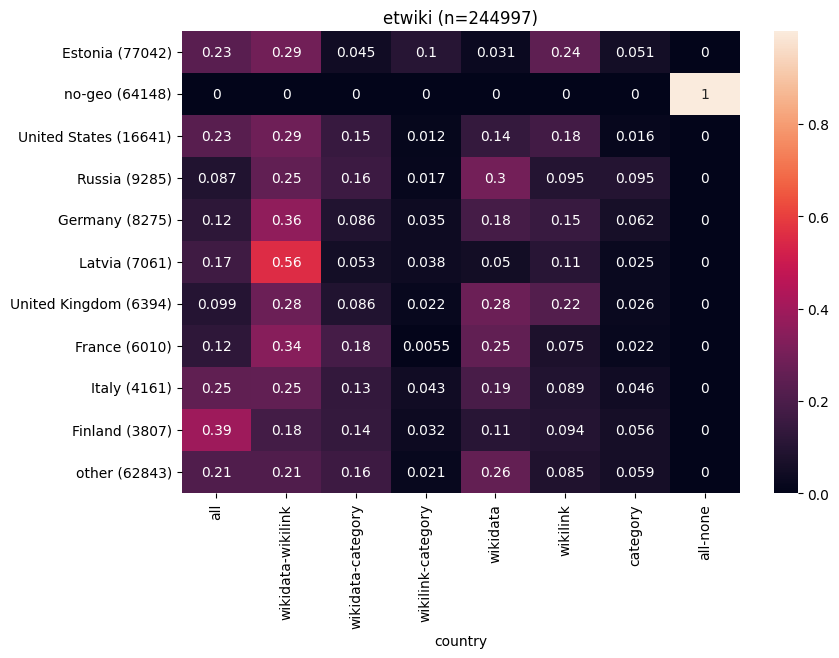

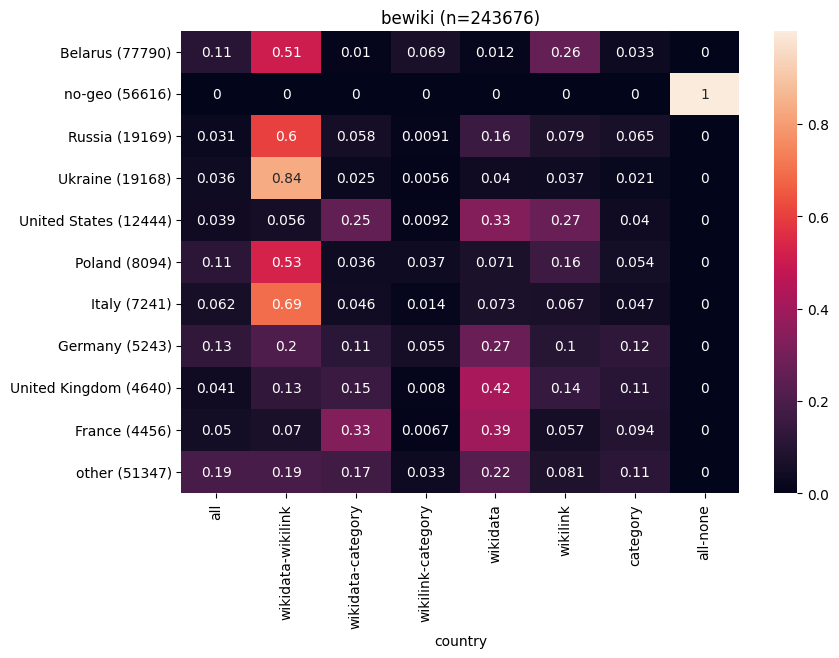

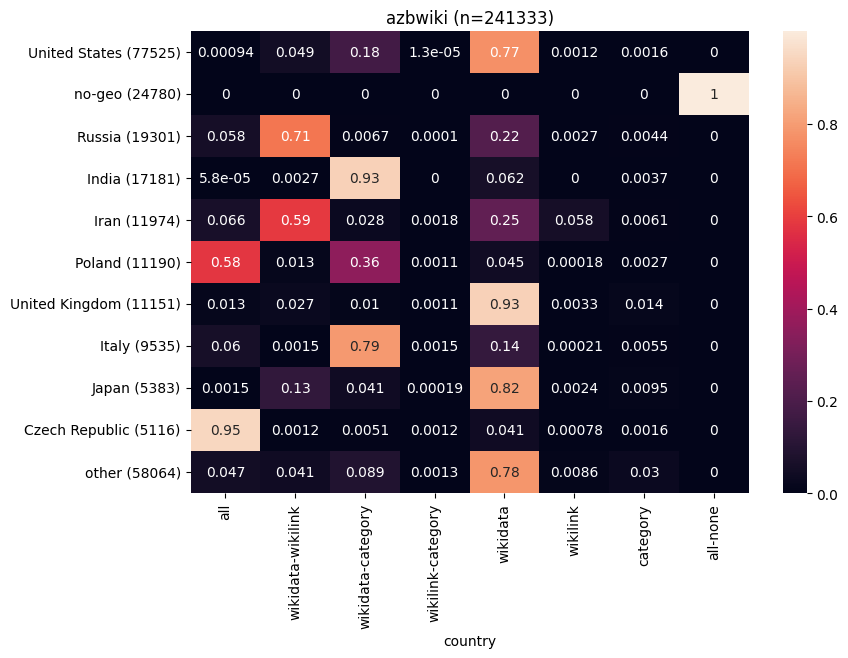

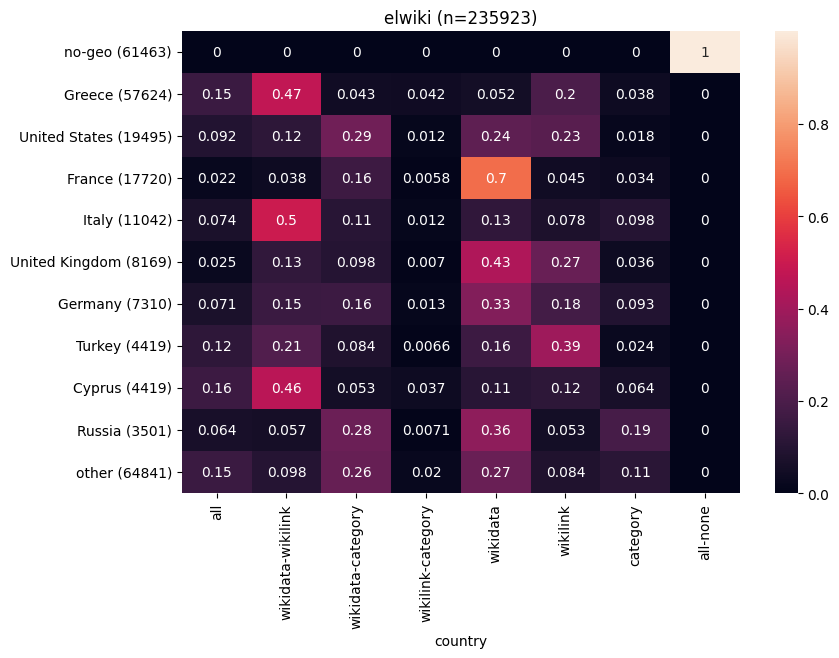

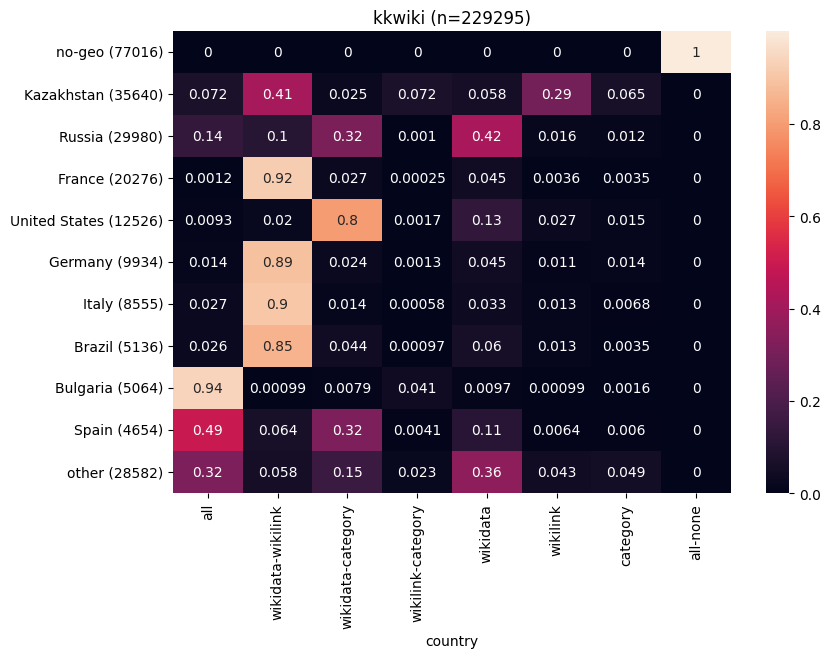

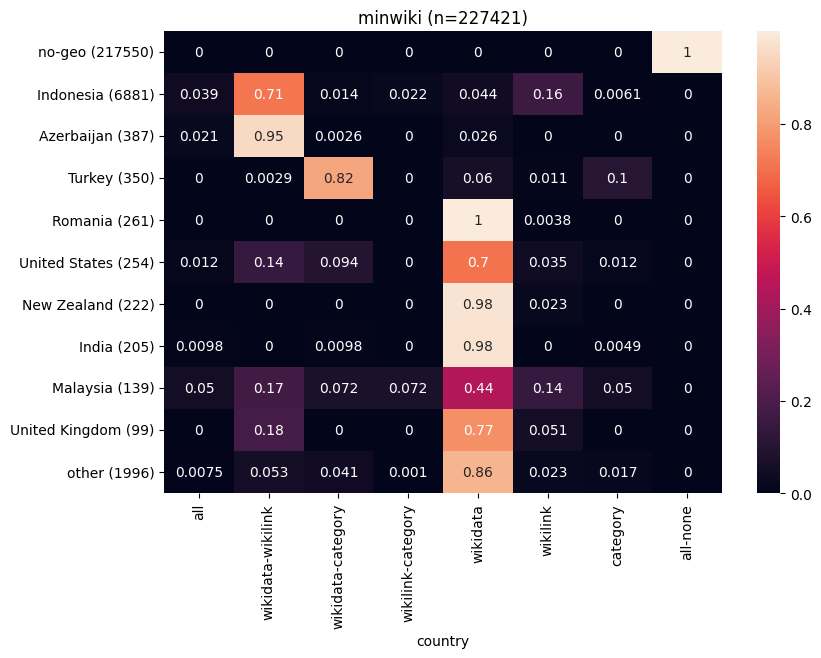

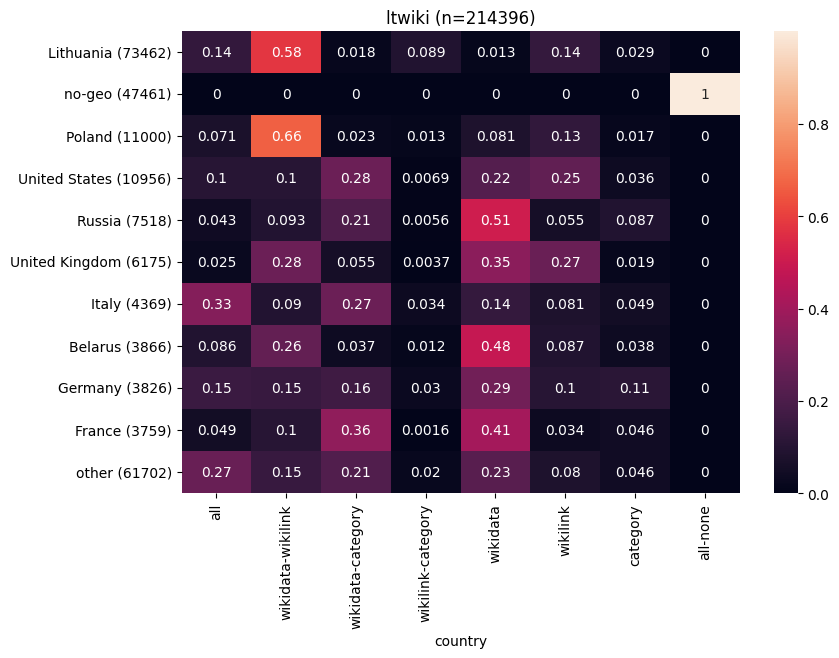

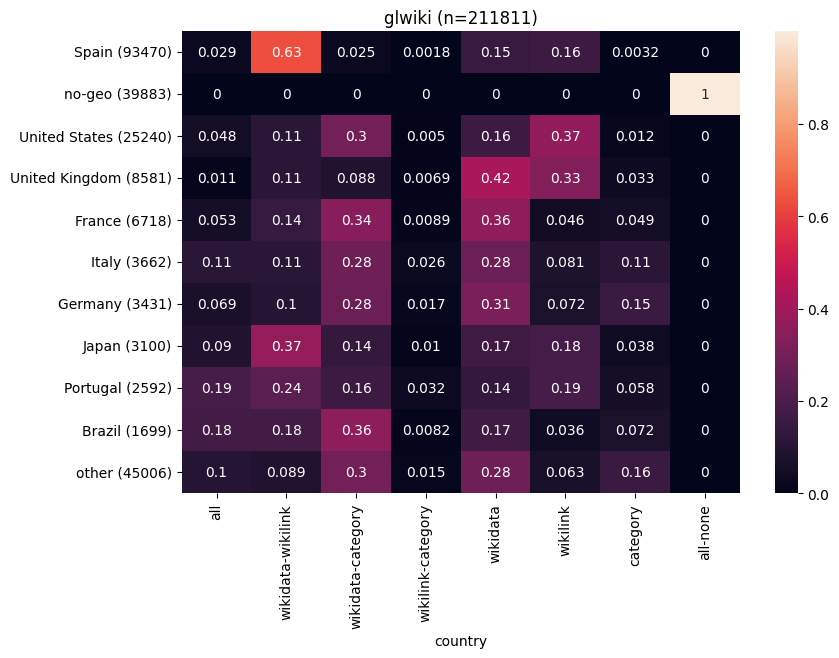

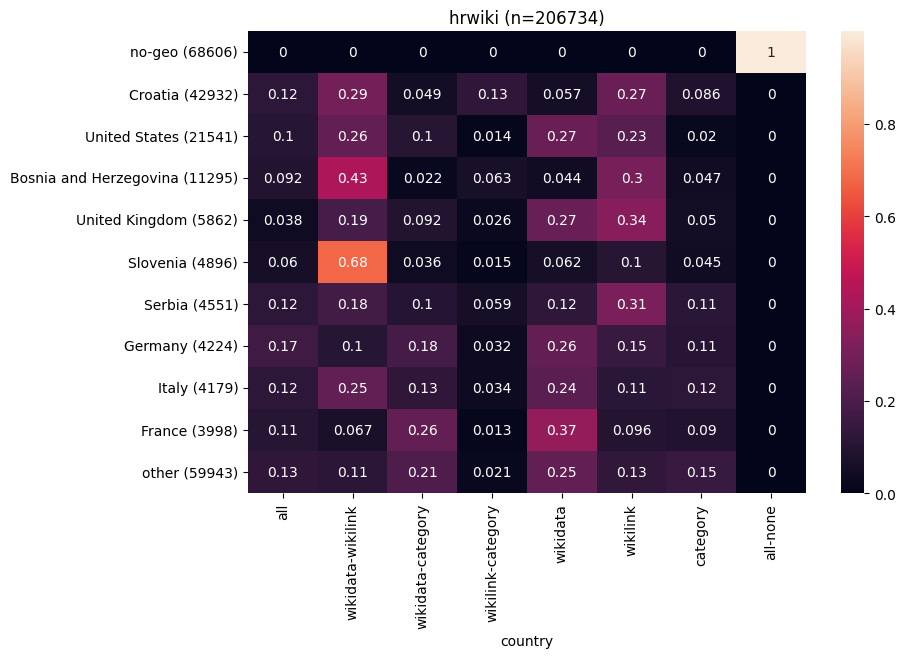

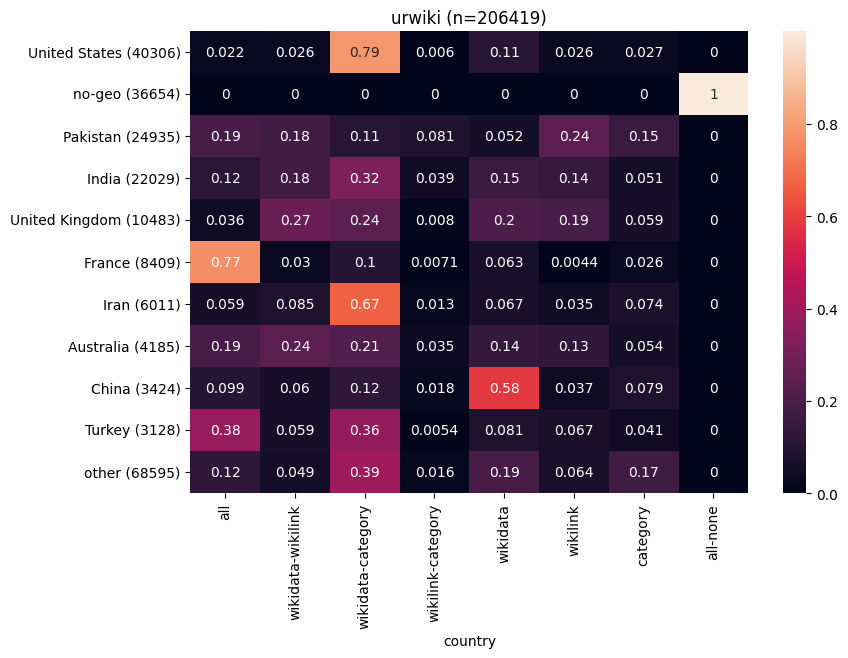

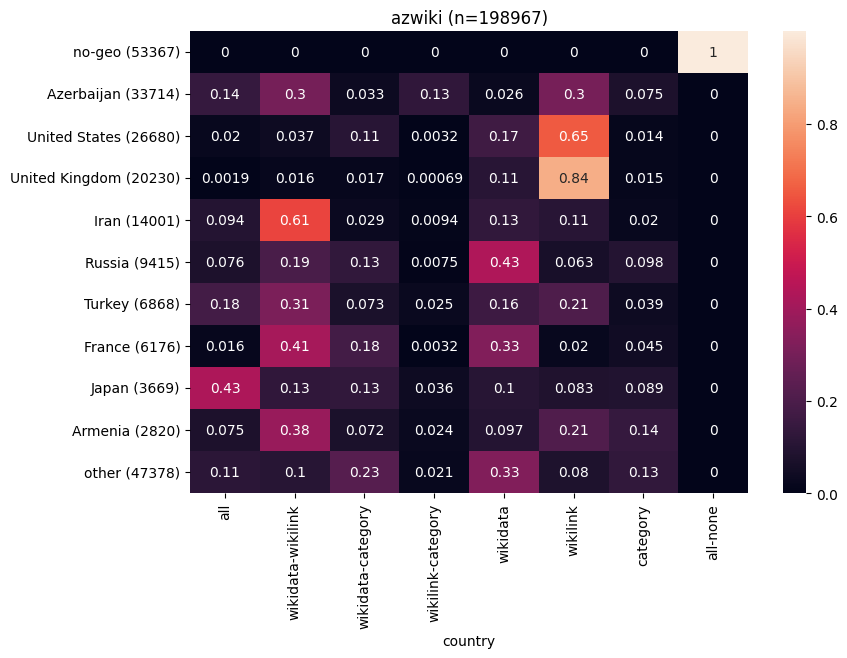

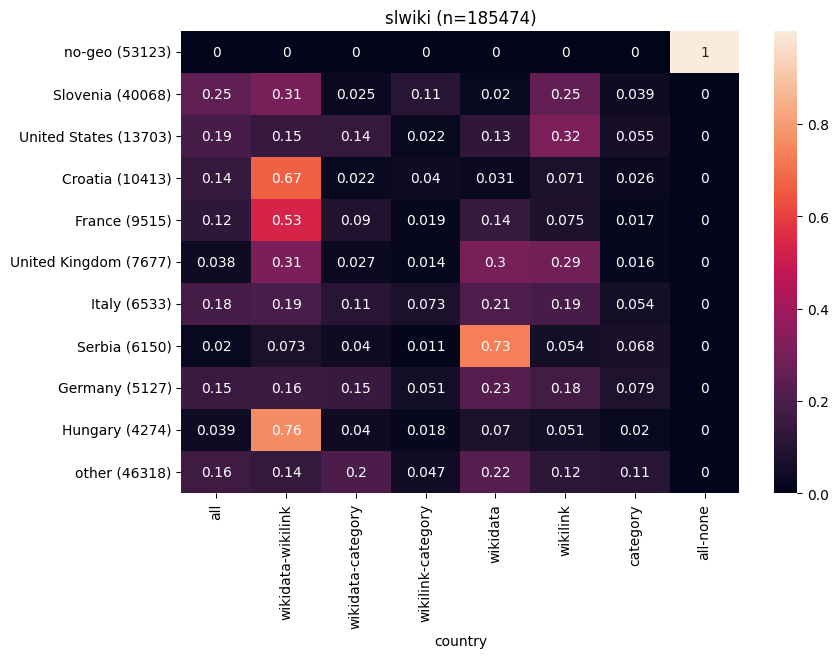

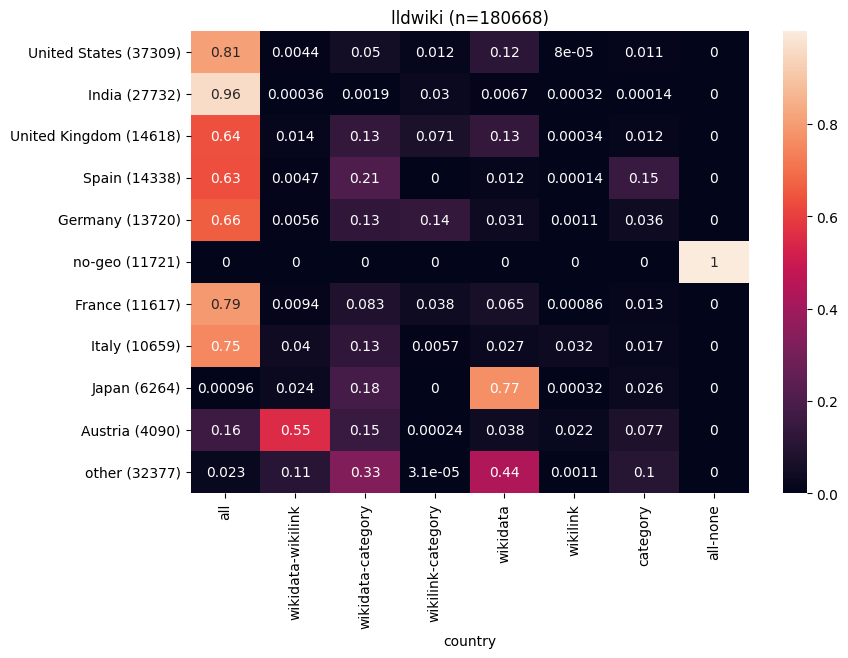

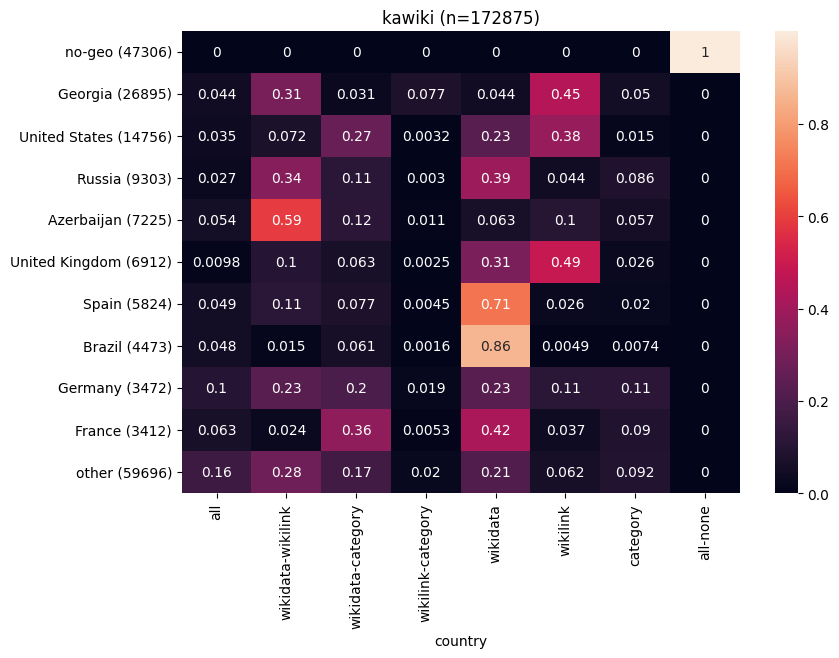

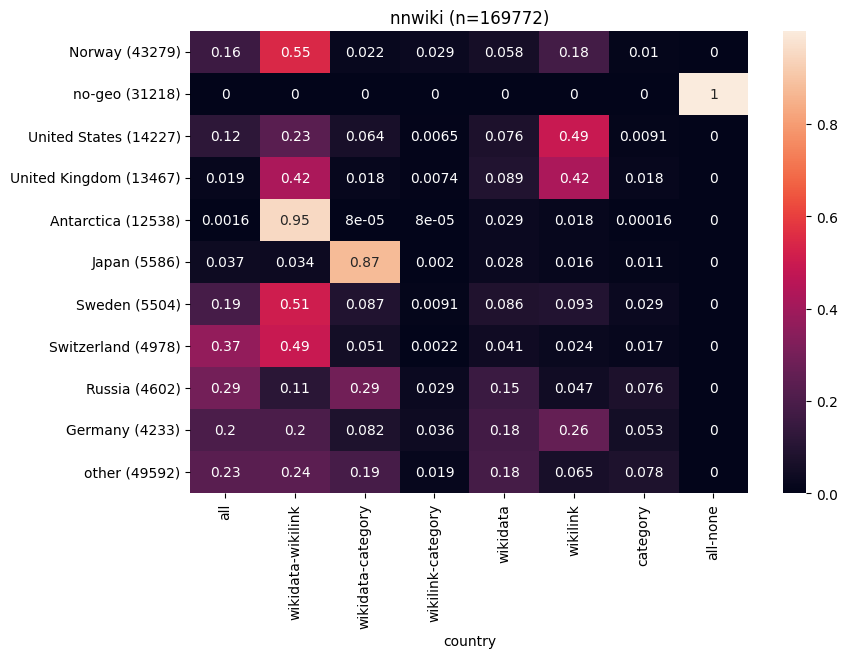

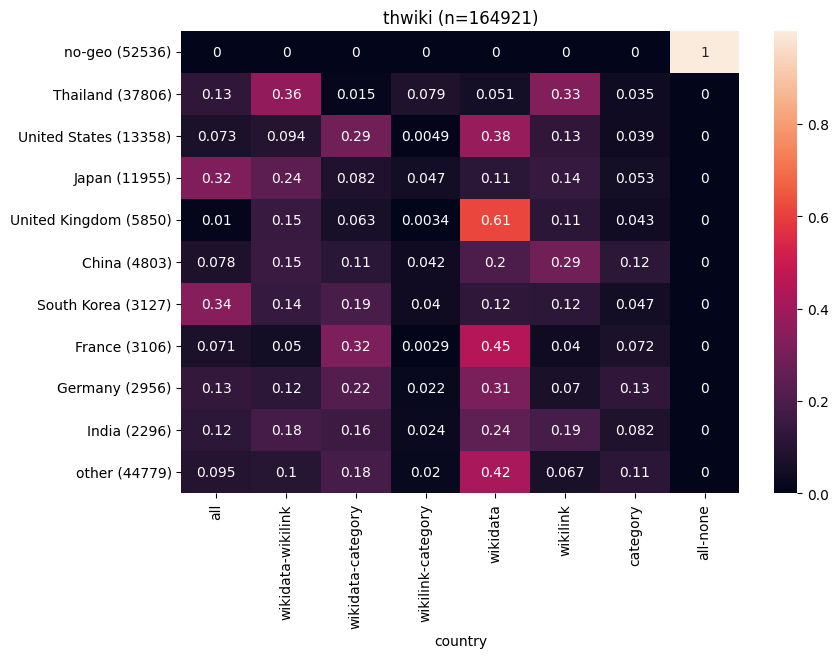

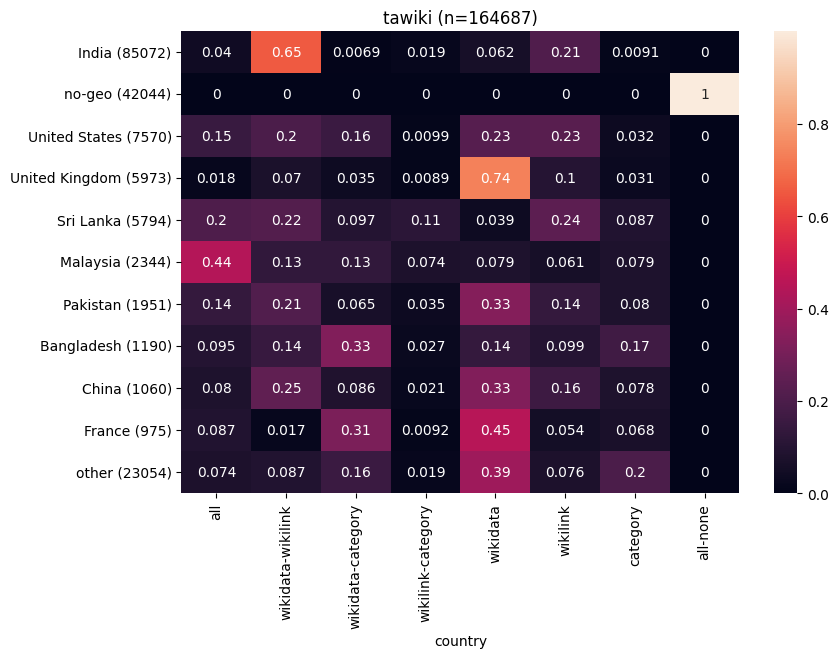

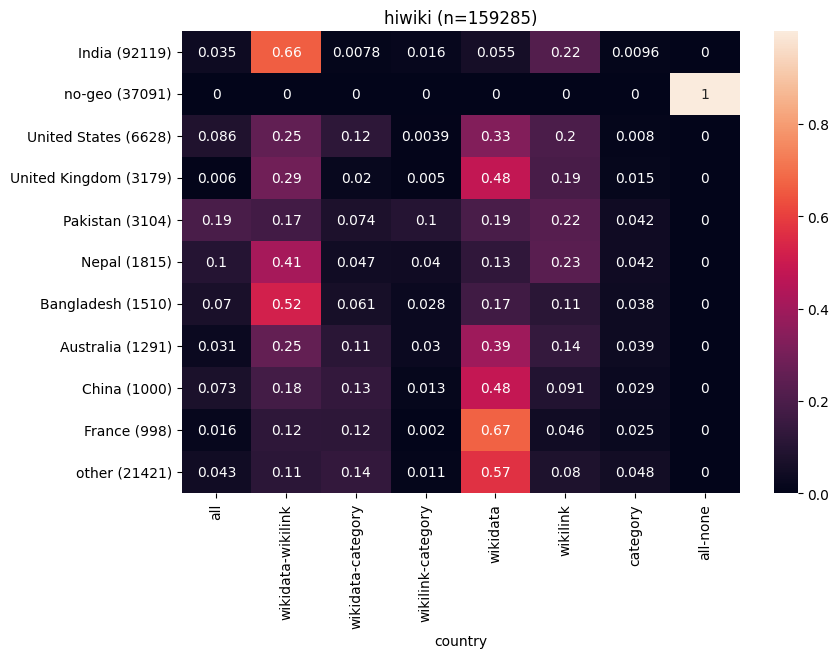

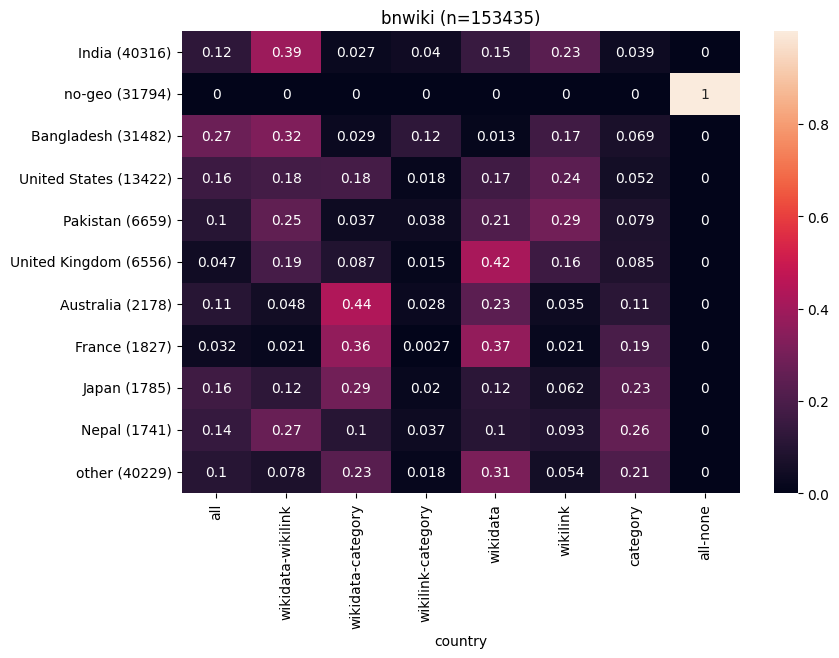

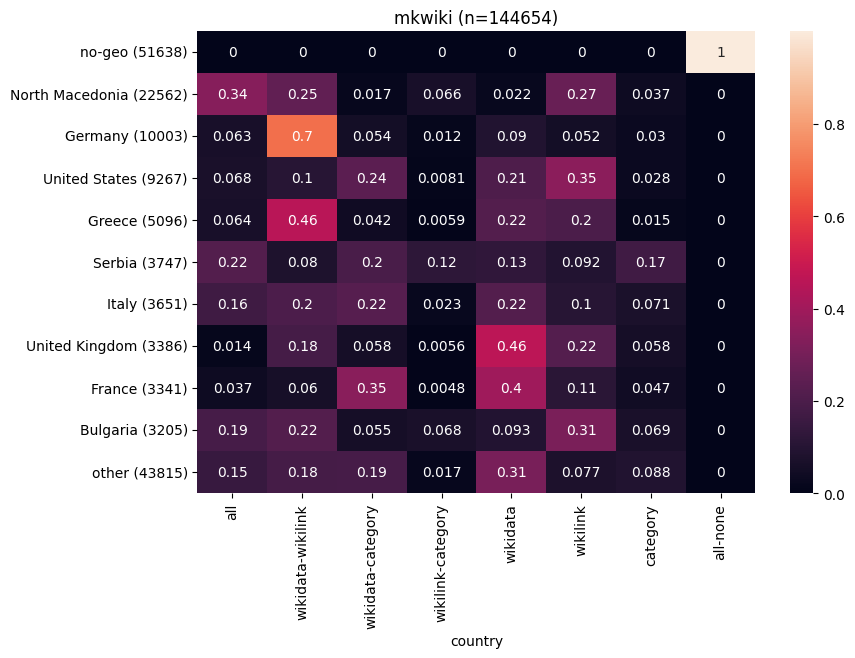

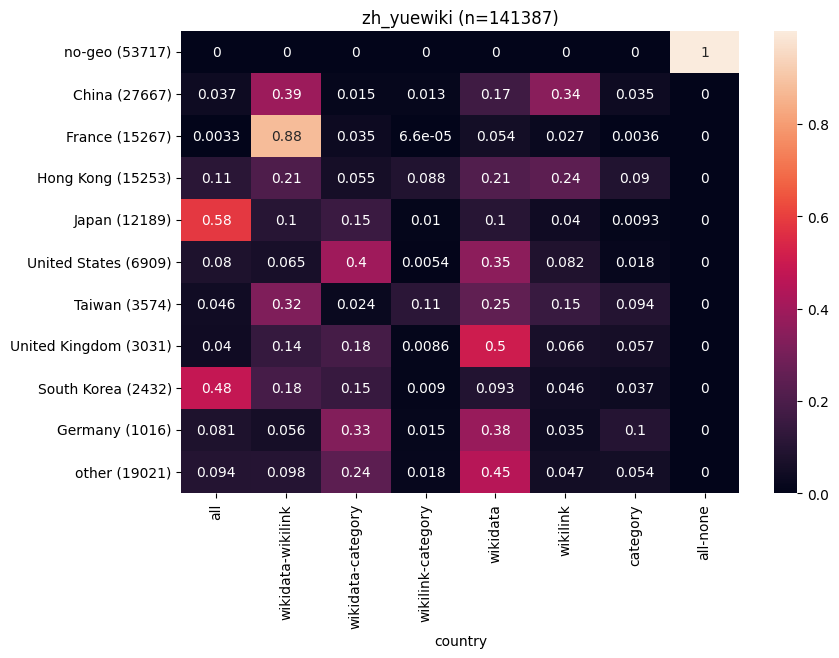

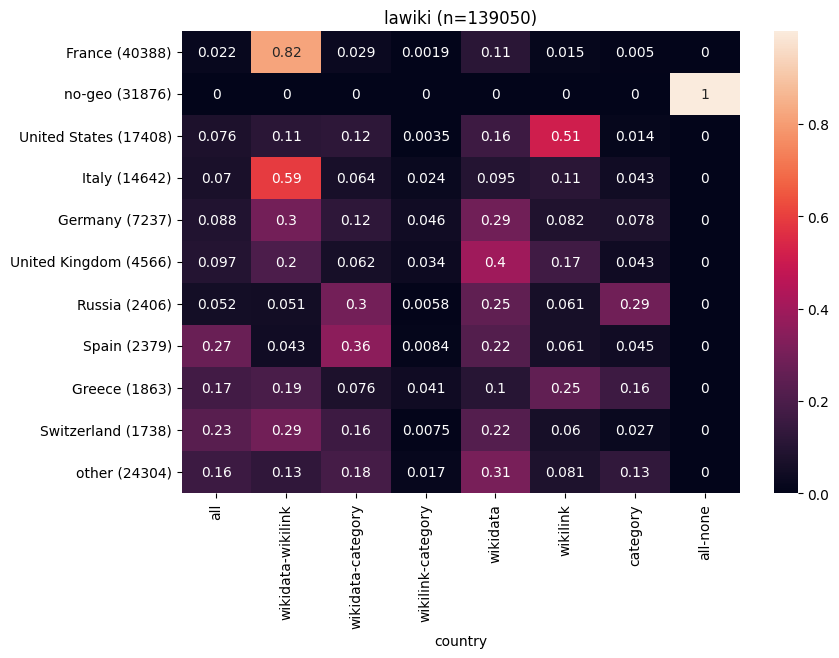

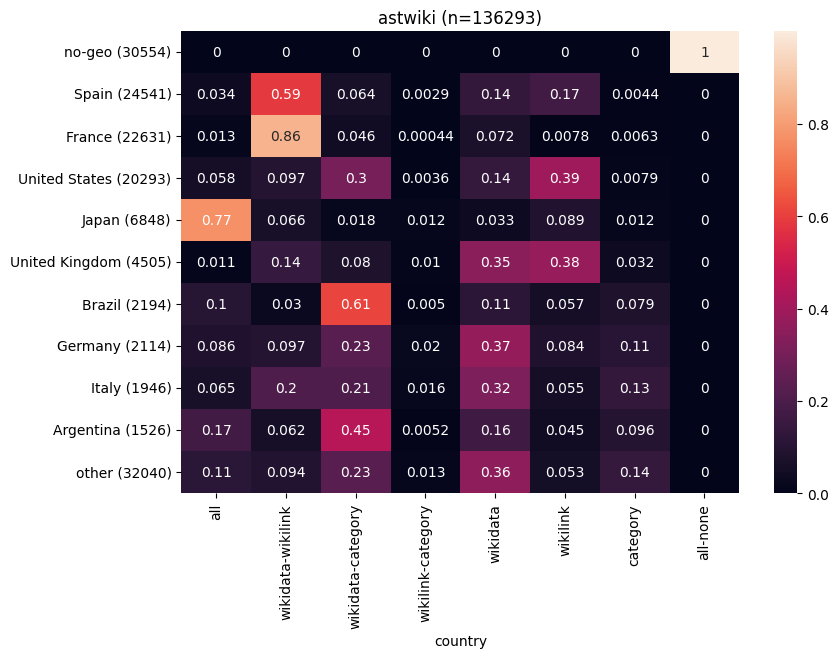

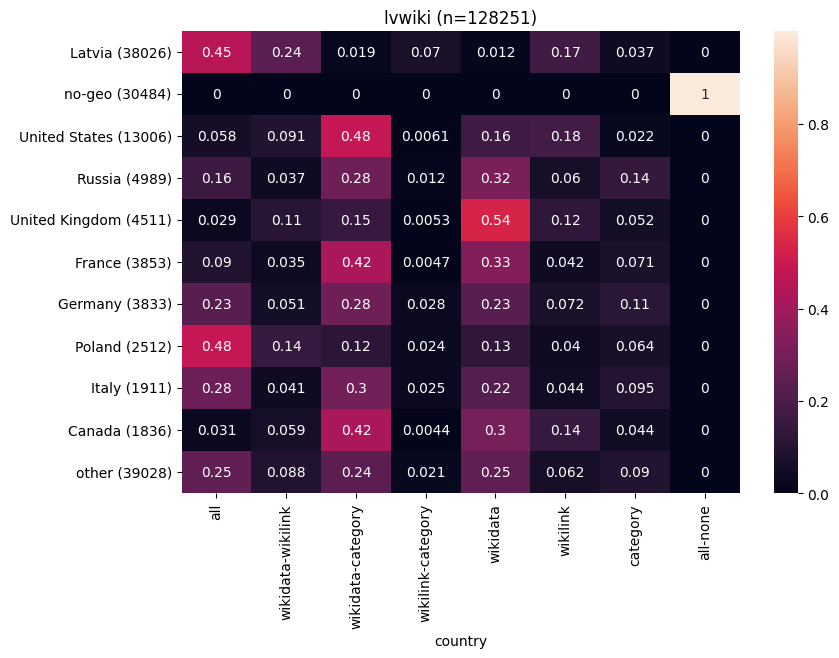

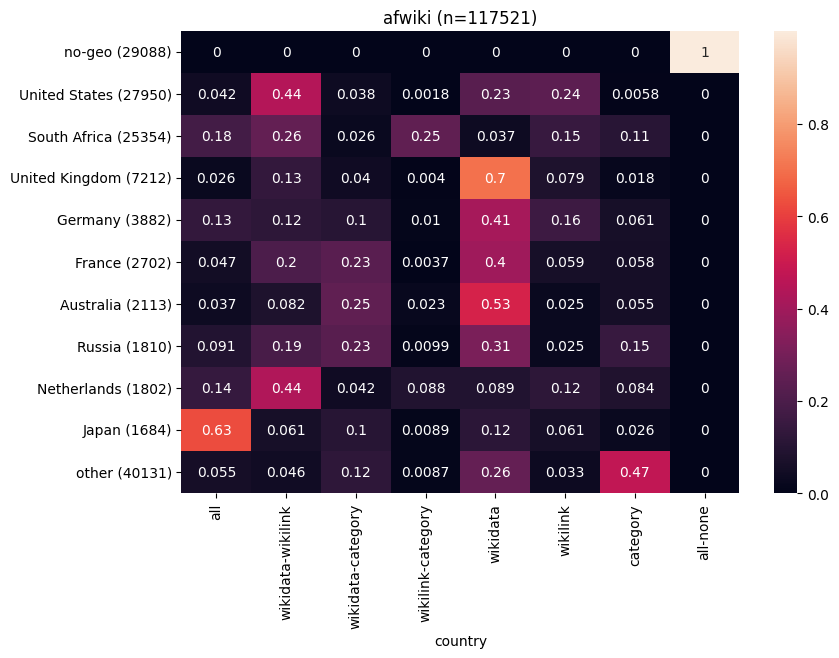

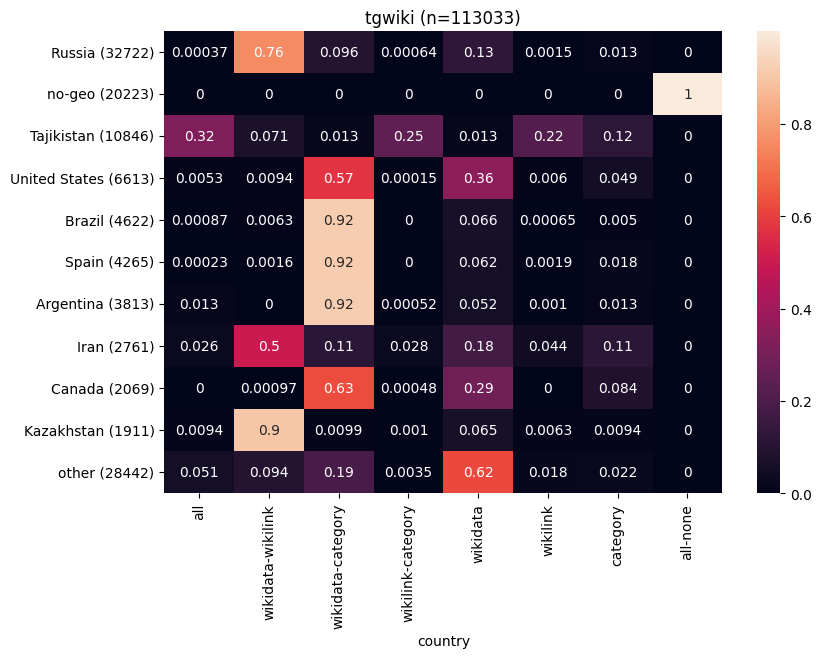

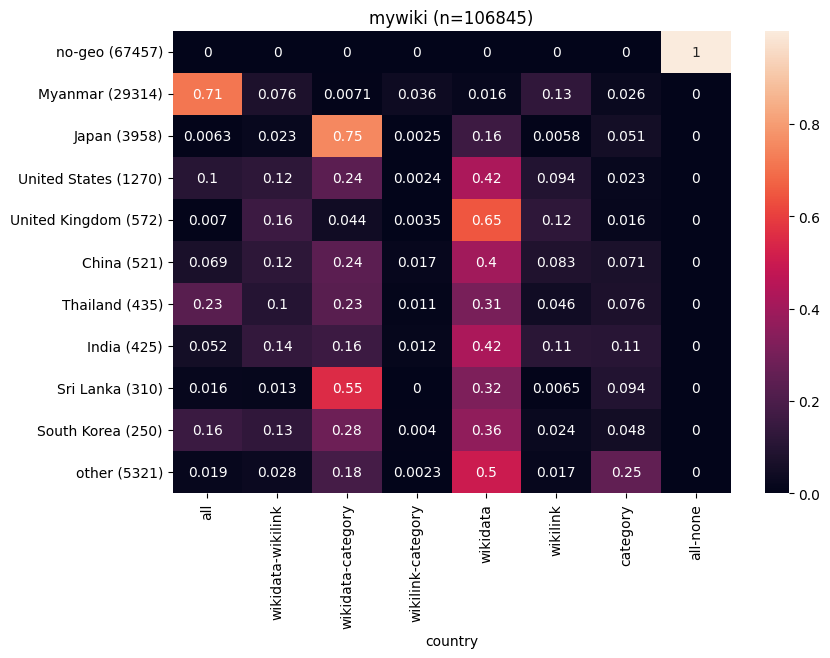

In [139]:
keep_k = 10
columns = ['country', 'alignment', 'count']
for wiki in sorted(article_count, key=article_count.get, reverse=True):
    if article_count[wiki] < 100000:
        break
    rows = []
    for topic in data[wiki]:
        if topic == 'all-articles':
            for country in data[wiki][topic]:
                for alignment, count in data[wiki][topic][country].items():
                    rows.append((country, alignment, count))
    df = pd.DataFrame(rows, columns=columns)
    analyze_model_performance(df, x_axis='country', y_axis='alignment', y_axis_order=alignment_order, keep_k=10, title=f"{wiki} (n={article_count[wiki]})")

In [26]:
rows = []
for wiki in data:
    for topic in data[wiki]:
        topic_article_count = data[wiki][topic]['article-count']
        if topic_article_count > 10000:
            for country in data[wiki][topic]:
                if country != 'article-count':
                    country_article_count = sum(data[wiki][topic][country].values())
                    if country_article_count > 1000:
                        try:
                            prop_wikilink = data[wiki][topic][country]['wikilink'] / country_article_count 
                            if prop_wikilink >= 0.5:
                                rows.append((wiki, topic, country, country_article_count, prop_wikilink))
                        except Exception:
                            continue
                    
topic_df = pd.DataFrame(rows, columns=['wiki', 'topic', 'country', 'article_count', 'prop_wikilink'])
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(topic_df.sort_values(by='article_count', ascending=False))

,wiki,topic,country,article_count,prop_wikilink
5,enwiki,Culture.Media.Music,United States,213221,0.628067
48,jawiki,Culture.Media.Media*,Japan,186632,0.503981
9,enwiki,Culture.Media.Media*,United Kingdom,158273,0.508261
403,trwiki,all-articles,United States,105746,0.509807
77,zhwiki,Culture.Biography.Biography*,China,82092,0.544742
49,jawiki,Culture.Media.Music,Japan,80574,0.679785
4,enwiki,Culture.Media.Music,United Kingdom,73418,0.713994
232,itwiki,Culture.Media.Music,United States,71788,0.699337
404,trwiki,all-articles,United Kingdom,58197,0.599447
367,cebwiki,all-articles,Thailand,54699,0.555056


In [27]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(topic_df.sort_values(by='prop_wikilink', ascending=False)[:100])

,wiki,topic,country,article_count,prop_wikilink
382,cebwiki,no-topic,Bosnia and Herzegovina,1032,1.000000
378,cebwiki,no-topic,Angola,3295,0.999697
386,cebwiki,no-topic,Finland,5651,0.999646
398,cebwiki,Culture.Linguistics,Afghanistan,6257,0.999521
380,cebwiki,no-topic,Australia,5515,0.999456
381,cebwiki,no-topic,Canada,15246,0.999278
390,cebwiki,no-topic,Austria,1301,0.999231
374,cebwiki,no-topic,Dominican Republic,1294,0.999227
383,cebwiki,no-topic,Brazil,5505,0.999092
376,cebwiki,no-topic,Germany,8097,0.999012


In [14]:
# examine a given wiki+country+topic for wikilinks
wiki = 'zhwiki'
topic = 'Culture.Biography.Biography*'
country = 'China'
sample_size = 20

predictions_tsv = "region-predictions-2024-Juneish.tsv.gz"
expected_header = ['wiki_db', 'page_id', 'qid_from', 'topics', 'category_countries', 'wikilink_countries', 'wikidata_countries']
wiki_idx = expected_header.index('wiki_db')
topics_idx = expected_header.index('topics')
cat_idx = expected_header.index('category_countries')
link_idx = expected_header.index('wikilink_countries')
wd_idx = expected_header.index('wikidata_countries')
found = 0
null_geo = set(['""'])
with gzip.open(predictions_tsv, 'rt') as fin:
    assert next(fin).strip().split('\t') == expected_header
    for i, line in enumerate(fin, start=0):
        try:
            line = line.strip().split('\t')
            if line[wiki_idx] == wiki:
                if topic in line[topics_idx]:
                    if country in line[link_idx]:
                        print(line)
                        found += 1
                        if found == sample_size:
                            break
        except Exception:
            continue

['zhwiki', '494777', 'Q10035524', 'Geography.Regions.Asia.East_Asia|Geography.Regions.Asia.Asia*|Culture.Biography.Biography*', 'China', 'China', '""']
['zhwiki', '31634', 'Q10379485', 'Culture.Biography.Biography*|Geography.Regions.Asia.Asia*|Geography.Regions.Asia.East_Asia', '""', 'China', 'China']
['zhwiki', '7298952', 'Q104105287', 'Culture.Biography.Biography*|History_and_Society.Politics_and_government', '""', 'United States|China', 'China']
['zhwiki', '7307093', 'Q104782483', 'Geography.Regions.Asia.East_Asia|Geography.Regions.Asia.Asia*|Culture.Biography.Biography*', '""', 'China', '""']
['zhwiki', '7237929', 'Q104783015', 'Geography.Regions.Asia.East_Asia|Geography.Regions.Asia.Asia*|Culture.Biography.Biography*', '""', 'China', '""']
['zhwiki', '141936', 'Q10481711', 'Geography.Regions.Asia.East_Asia|Geography.Regions.Asia.Asia*|Culture.Biography.Biography*', '""', 'China', '""']
['zhwiki', '1298511', 'Q10513704', 'Geography.Regions.Asia.Asia*|Geography.Regions.Asia.East_Asi

In [15]:
# examine a given wiki+country+topic for wikilinks
wiki = 'enwiki'
topic = 'Culture.Media.Music'
country = 'United States'
sample_size = 20

predictions_tsv = "region-predictions-2024-Juneish.tsv.gz"
expected_header = ['wiki_db', 'page_id', 'qid_from', 'topics', 'category_countries', 'wikilink_countries', 'wikidata_countries']
wiki_idx = expected_header.index('wiki_db')
topics_idx = expected_header.index('topics')
cat_idx = expected_header.index('category_countries')
link_idx = expected_header.index('wikilink_countries')
wd_idx = expected_header.index('wikidata_countries')
found = 0
null_geo = set(['""'])
with gzip.open(predictions_tsv, 'rt') as fin:
    assert next(fin).strip().split('\t') == expected_header
    for i, line in enumerate(fin, start=0):
        try:
            line = line.strip().split('\t')
            if line[wiki_idx] == wiki:
                if topic in line[topics_idx]:
                    if country in line[link_idx]:
                        print(line)
                        found += 1
                        if found == sample_size:
                            break
        except Exception:
            continue

['enwiki', '65584942', 'Q100710412', 'Culture.Media.Media*|Culture.Media.Music', '""', 'United States', '""']
['enwiki', '621277', 'Q1026811', 'Culture.Media.Music|Culture.Media.Media*', '""', 'United States', '""']
['enwiki', '2371881', 'Q10340425', 'Culture.Media.Media*|Culture.Media.Music', '""', 'United States', '""']
['enwiki', '2443834', 'Q1034075', 'Culture.Media.Media*|Culture.Media.Music|Culture.Biography.Women|Culture.Biography.Biography*', 'Switzerland', 'United States', 'United States']
['enwiki', '64857607', 'Q104848040', 'Culture.Media.Music|Culture.Media.Media*|Geography.Regions.Europe.Northern_Europe|Geography.Regions.Europe.Europe*', '""', 'United States', '""']
['enwiki', '66008558', 'Q104878428', 'Culture.Media.Music|Culture.Media.Media*', '""', 'United States', 'United States']
['enwiki', '66262824', 'Q104882739', 'Culture.Media.Music|Culture.Media.Media*|Geography.Regions.Europe.Europe*|Geography.Regions.Europe.Northern_Europe', 'United Kingdom', 'United States|Uni

24/07/26 14:22:26 WARN JavaUtils: Attempt to delete using native Unix OS command failed for path = /srv/spark-tmp/blockmgr-fdc3e938-a5cd-4ad0-a1b9-50c8529022dc. Falling back to Java IO way
java.io.IOException: Failed to delete: /srv/spark-tmp/blockmgr-fdc3e938-a5cd-4ad0-a1b9-50c8529022dc
	at org.apache.spark.network.util.JavaUtils.deleteRecursivelyUsingUnixNative(JavaUtils.java:171)
	at org.apache.spark.network.util.JavaUtils.deleteRecursively(JavaUtils.java:110)
	at org.apache.spark.network.util.JavaUtils.deleteRecursively(JavaUtils.java:91)
	at org.apache.spark.util.Utils$.deleteRecursively(Utils.scala:1141)
	at org.apache.spark.storage.DiskBlockManager.$anonfun$doStop$1(DiskBlockManager.scala:182)
	at org.apache.spark.storage.DiskBlockManager.$anonfun$doStop$1$adapted(DiskBlockManager.scala:178)
	at scala.collection.IndexedSeqOptimized.foreach(IndexedSeqOptimized.scala:36)
	at scala.collection.IndexedSeqOptimized.foreach$(IndexedSeqOptimized.scala:33)
	at scala.collection.mutable.Ar